In [10]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [8]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

# 다른 폰트를 기본으로 하려면
# from matplotlib.font_manager import FontProperties, fontManager
# font_path = 'data/font/온글잎밑미.ttf'
# #font_path = "c:/Windows/Fonts/H2PORM.TTF"
# fontproperties = FontProperties(fname=font_path, size=30)
# fontManager.addfont(file_path) # windows폴더에 있지 않는 ttf파일일 경우 
# font_name = fontproperties.get_name()

# 한글설정 및 미적속성 설정
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3),
           'font.family':'Malgun Gothic',
           # font.family':font_nama,
           #'font.size':20,
           'axes.unicode_minus':False})

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안보이게
# warnings.filterwarnings(action='default') # 경고 메세지 보이게

# 2. 데이터 다운받아, 서울과 부산데이터만 df변수에 읽어온다

In [5]:
%ls "c:/ai/Downloads/shareData/상가정보/"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 1828-3575

 c:\ai\Downloads\shareData\상가정보 디렉터리

2026-07-24  오후 03:36    <DIR>          .
2026-07-22  오후 02:56    <DIR>          ..
2025-11-03  오전 12:45             1,011 [필독]파일열람방법.txt
2026-07-24  오후 12:16    <DIR>          새 폴더
2026-07-24  오후 03:36       221,258,075 서울부산상가정보백업.csv
2026-04-27  오전 11:10        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-04-27  오전 11:10       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-04-27  오전 11:10         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
               5개 파일         607,886,714 바이트
               3개 디렉터리  773,927,612,416 바이트 남음


In [6]:
# 서울시 소상공인 데이터(warring 해결방법1)
df_seoul = pd.read_csv('c:/ai/Downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                      low_memory=False # 파일 전체를 한번에 읽어서 타입을 일관되게 추론
                      )
df_seoul

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,NaN,G2,소매,G214,연료 소매,G21401,주유소,G47711,...,1147010200101210004019571,NaN,서울특별시 양천구 안양천로 1171,158052,7969,NaN,NaN,NaN,126.882157,37.545315
537485,MA0106202601A2413483,뷰티에이지,NaN,S2,수리·개인,S207,이용·미용,S20701,미용실,S96111,...,1168010100107250051023877,NaN,서울특별시 강남구 테헤란로30길 31,135921,6223,NaN,NaN,NaN,127.040045,37.499253
537486,MA0106202601A0824946,리나스 예술의전당점,NaN,I2,음식,I201,한식,I20101,백반/한정식,I56111,...,1165010800107150000021704,NaN,서울특별시 서초구 남부순환로 2406,137718,6757,NaN,NaN,NaN,127.014144,37.480338
537487,MA0106202601A1120245,제이라스 스튜디오,NaN,G2,소매,G209,섬유·의복·신발 소매,G20903,유아용 의류 소매업,G47417,...,1114011200100460031000001,NaN,서울특별시 중구 남대문시장8길 16,100804,4529,NaN,NaN,NaN,126.978315,37.559697


In [9]:
# 서울시 소상공인 데이터(warring 해결방법2)
df_seoul = pd.read_csv('c:/ai/Downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                      dtype={'층정보':str} # 35번째 층정보 열을 str로 고정
                      )
df_seoul

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,NaN,G2,소매,G214,연료 소매,G21401,주유소,G47711,...,1147010200101210004019571,NaN,서울특별시 양천구 안양천로 1171,158052,7969,NaN,NaN,NaN,126.882157,37.545315
537485,MA0106202601A2413483,뷰티에이지,NaN,S2,수리·개인,S207,이용·미용,S20701,미용실,S96111,...,1168010100107250051023877,NaN,서울특별시 강남구 테헤란로30길 31,135921,6223,NaN,NaN,NaN,127.040045,37.499253
537486,MA0106202601A0824946,리나스 예술의전당점,NaN,I2,음식,I201,한식,I20101,백반/한정식,I56111,...,1165010800107150000021704,NaN,서울특별시 서초구 남부순환로 2406,137718,6757,NaN,NaN,NaN,127.014144,37.480338
537487,MA0106202601A1120245,제이라스 스튜디오,NaN,G2,소매,G209,섬유·의복·신발 소매,G20903,유아용 의류 소매업,G47417,...,1114011200100460031000001,NaN,서울특별시 중구 남대문시장8길 16,100804,4529,NaN,NaN,NaN,126.978315,37.559697


In [10]:
# 정확한 메모이 사용량
df_seoul.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  object 
 1   상호명        537489 non-null  object 
 2   지점명        47001 non-null   object 
 3   상권업종대분류코드  537489 non-null  object 
 4   상권업종대분류명   537489 non-null  object 
 5   상권업종중분류코드  537489 non-null  object 
 6   상권업종중분류명   537489 non-null  object 
 7   상권업종소분류코드  537489 non-null  object 
 8   상권업종소분류명   537489 non-null  object 
 9   표준산업분류코드   537291 non-null  object 
 10  표준산업분류명    537291 non-null  object 
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  object 
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  object 
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  object 
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  object 
 19  지번코드       537489 non-n

In [11]:
df_seoul.head(1).T

,0
상가업소번호,MA010120220800800619
상호명,참편한공인중개사사무소
지점명,NaN
상권업종대분류코드,L1
상권업종대분류명,부동산
상권업종중분류코드,L102
상권업종중분류명,부동산 서비스
상권업종소분류코드,L10203
상권업종소분류명,부동산 중개/대리업
표준산업분류코드,L68221


In [14]:
# 부산 소상공인 데이터
df_busan = pd.read_csv('c:/ai/Downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_부산_202603.csv',
                      dtype={'층정보':str})
df_busan.head(1).T

,0
상가업소번호,MA010120220804863915
상호명,제이와이솔루션
지점명,NaN
상권업종대분류코드,G2
상권업종대분류명,소매
상권업종중분류코드,G215
상권업종중분류명,의약·화장품 소매
상권업종소분류코드,G21502
상권업종소분류명,의료기기 소매업
표준산업분류코드,G47812


In [16]:
# 서울소상공인데이터, 부산소상공인데이터 concat 전 : 동일 컬럼명 확인
np.all(df_seoul.columns == df_busan.columns)

True

In [19]:
# 서울소상공인데이터, 부산소상공인데이터 concat 전 : 컬럼 타입들 확인
np.all(df_seoul.dtypes == df_busan.dtypes)

False

In [21]:
# 타입이 다른 열이름 색출
result = df_seoul.dtypes == df_busan.dtypes
result[result==False]

건물본번지    False
dtype: bool

In [24]:
# 서울 건물본번지
print(df_seoul['건물본번지'].dtypes)
print(df_seoul['건물본번지'][:3])
# print(df_seoul.loc[:3, '건물본번지'])

float64
0     25.0
1      8.0
2    385.0
Name: 건물본번지, dtype: float64
0     25.0
1      8.0
2    385.0
3     30.0
Name: 건물본번지, dtype: float64


In [25]:
# 부산 건물본번지
print(df_busan['건물본번지'].dtypes)
print(df_busan['건물본번지'][:3])

int64
0     47
1    343
2     86
Name: 건물본번지, dtype: int64


In [27]:
print(df_seoul['건물본번지'].isna().sum())
print(df_busan['건물본번지'].isna().sum())

2
0


In [29]:
# 서울시 건물본번지가 결측치인 데이터 추축
df_seoul.loc[df_seoul['건물본번지'].isna(), ['상호명', '건물본번지']]

,상호명,건물본번지
81807,명함이야기,NaN
176031,명함랜드기프트랜드,NaN


In [33]:
# concat
df = pd.concat([df_seoul, df_busan]) # axis=0기본값
df.shape

(692592, 39)

In [34]:
print(df_seoul.index)
print(df_busan.index)

RangeIndex(start=0, stop=537489, step=1)
RangeIndex(start=0, stop=155103, step=1)


In [35]:
df.loc[0, ['상호명','시도명']]

,상호명,시도명
0,참편한공인중개사사무소,서울특별시
0,제이와이솔루션,부산광역시


In [36]:
# concat호 인덱스 정리
# df.index = range(df.shape[0])
df = df.reset_index(drop=True)
df.shape

(692592, 39)

In [ ]:
deldf

# 3. df 데이터 셋의 결측치 및 시각화
## ① df 변수의 컬럼들을 확인하고 상위 3줄, 하위3줄을 출력한다.

In [ ]:
# df.head(3)
# df.iloc[:3]
# df.loc[:2]
# df[0:3]

In [ ]:
df.tail(3)
df.iloc[-3:]

## ②	df 변수의 결측치를 제외한 데이터 개수 및 dtype들을 출력(dtypes함수)하고 변수가 사용되는 메모리 사용량 확인한다.

In [ ]:
df.info() # memory_usage='deep'

## ③	결측치를 확인하고 결측치가 없는 컬럼을 포함하여 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot)

In [37]:
# 열별 결측치 갯수
missing_cnt = df.isnull().sum()
missing_cnt.headd()

상가업소번호            0
상호명               1
지점명          630376
상권업종대분류코드         0
상권업종대분류명          0
dtype: int64

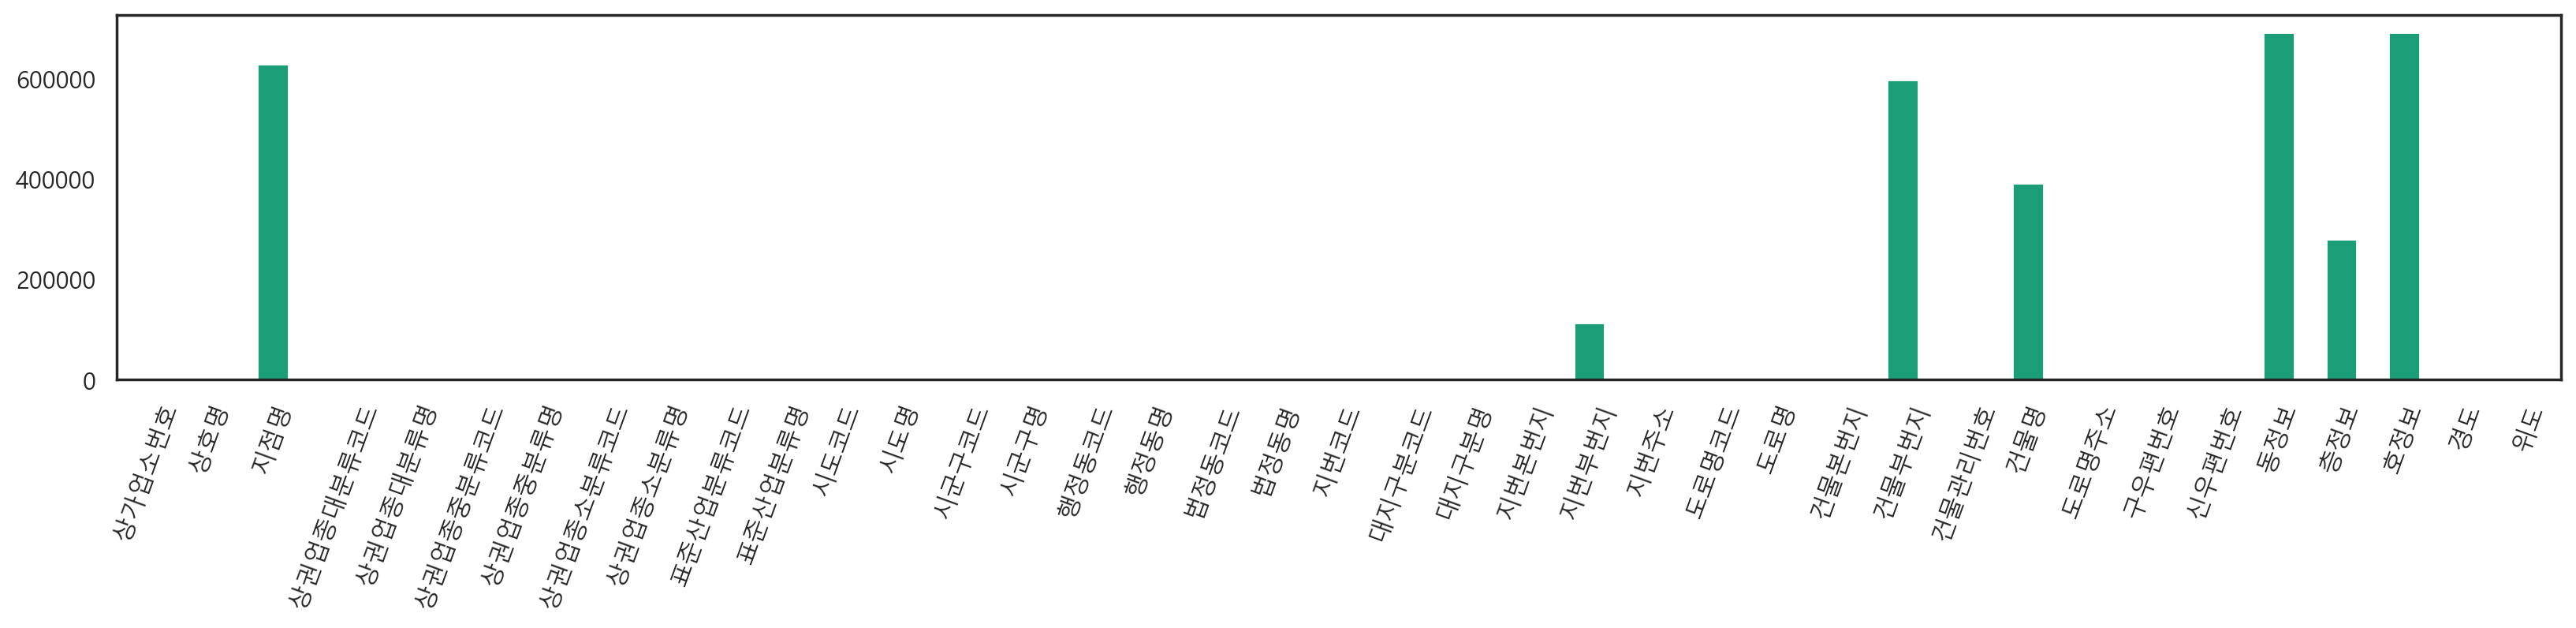

In [38]:
# missing_cnt.plot.bar()

missing_cnt.plot(kind='bar', figsize=(20,3), rot=70)
plt.show()

In [39]:
missing_cnt_sored = missing_cnt.sort_values(ascending=False)
missing_cnt_sored.head(2)

호정보    692592
동정보    692592
dtype: int64

<Axes: >

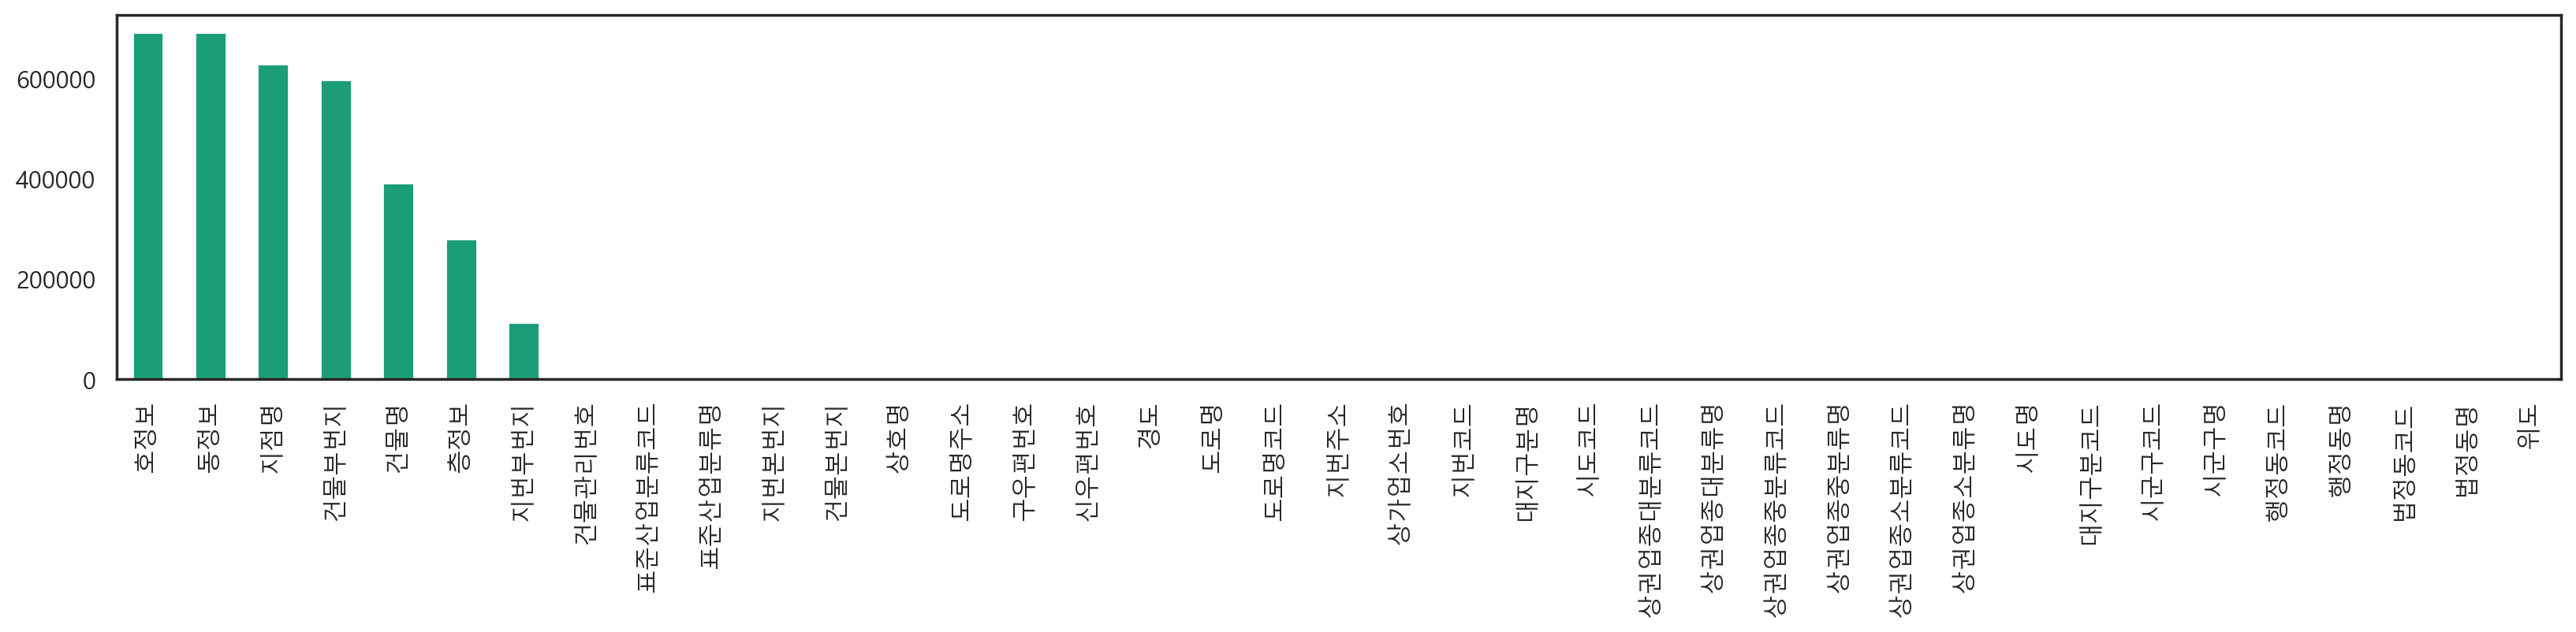

In [40]:
missing_cnt_sored.plot(kind='bar', figsize=(20, 3))
plt.show()

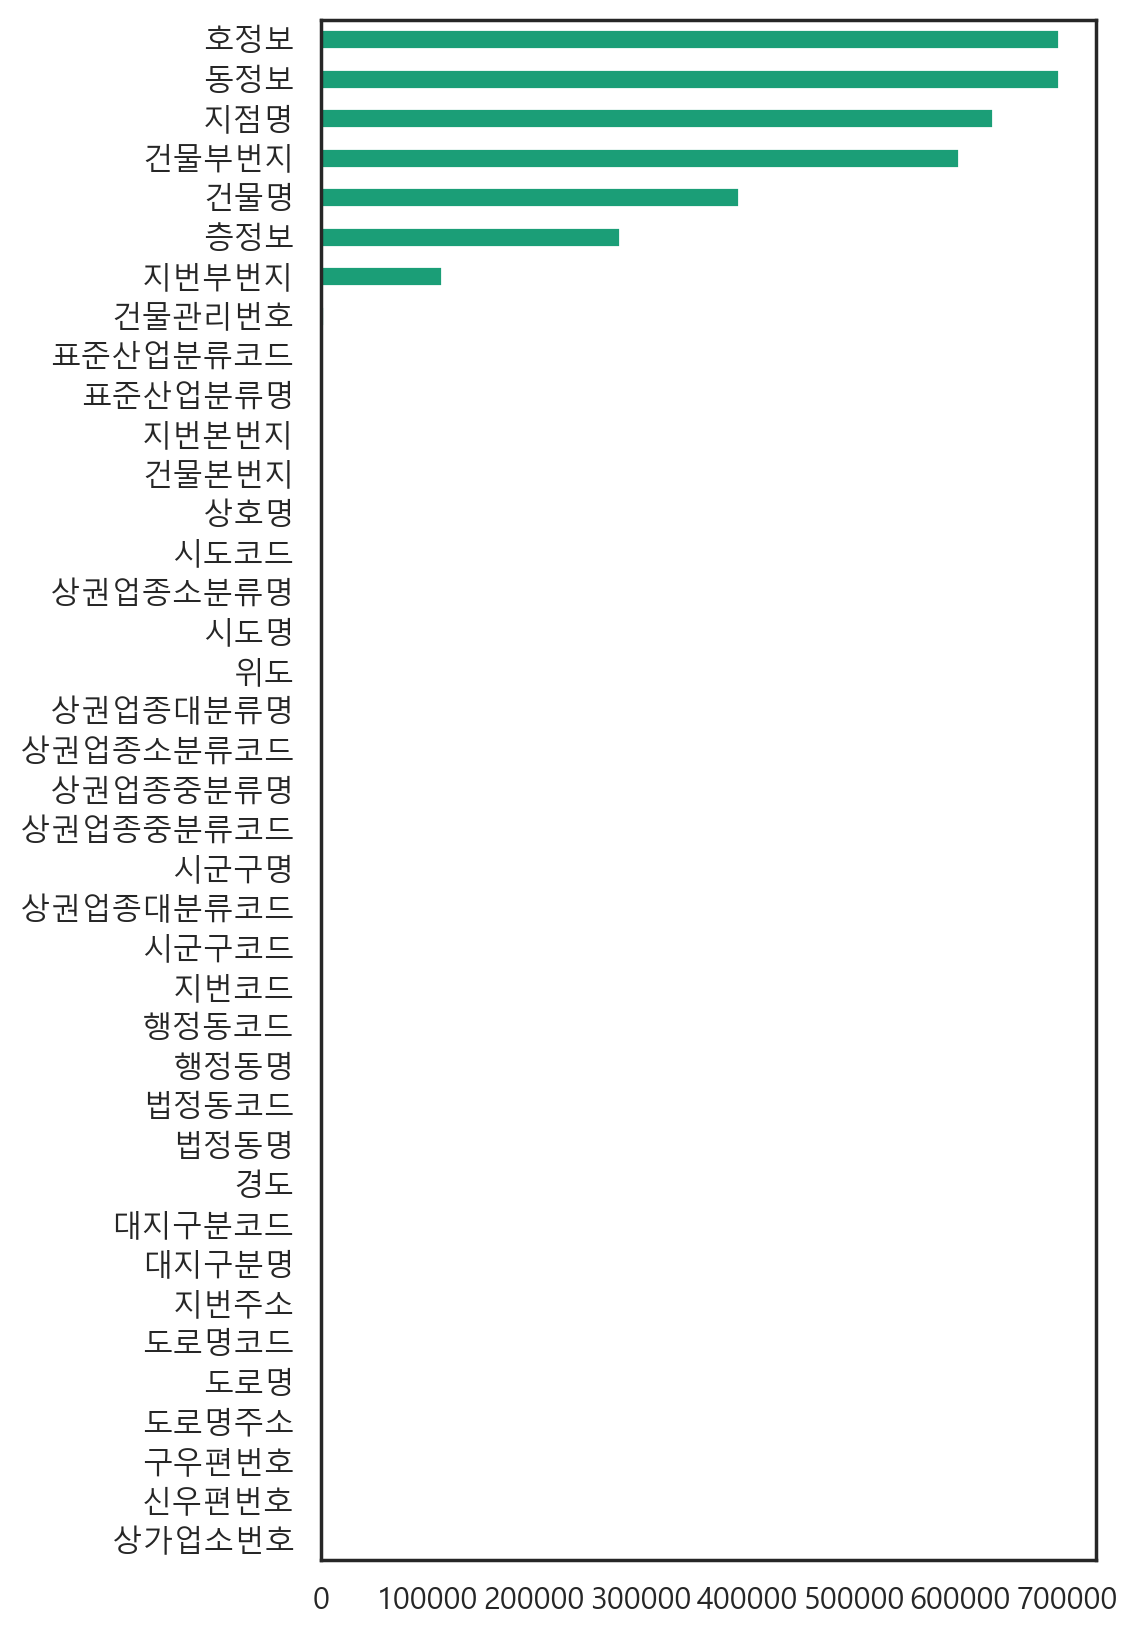

In [45]:
missing_cnt.sort_values().plot(kind='barh', figsize=(5, 10))
plt.show()

## ④ 결측치가 없는 컬럼는 제외하고 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot).

In [48]:
#결측치가 있는 열만
only_missing_cnt = missing_cnt[missing_cnt!=0]
for i,(col, val) in enumerate(only_missing_cnt.items()):
    print(i, col, val)

0 상호명 1
1 지점명 630376
2 표준산업분류코드 211
3 표준산업분류명 211
4 지번본번지 29
5 지번부번지 113977
6 건물본번지 2
7 건물부번지 598859
8 건물관리번호 2912
9 건물명 391896
10 동정보 692592
11 층정보 280540
12 호정보 692592


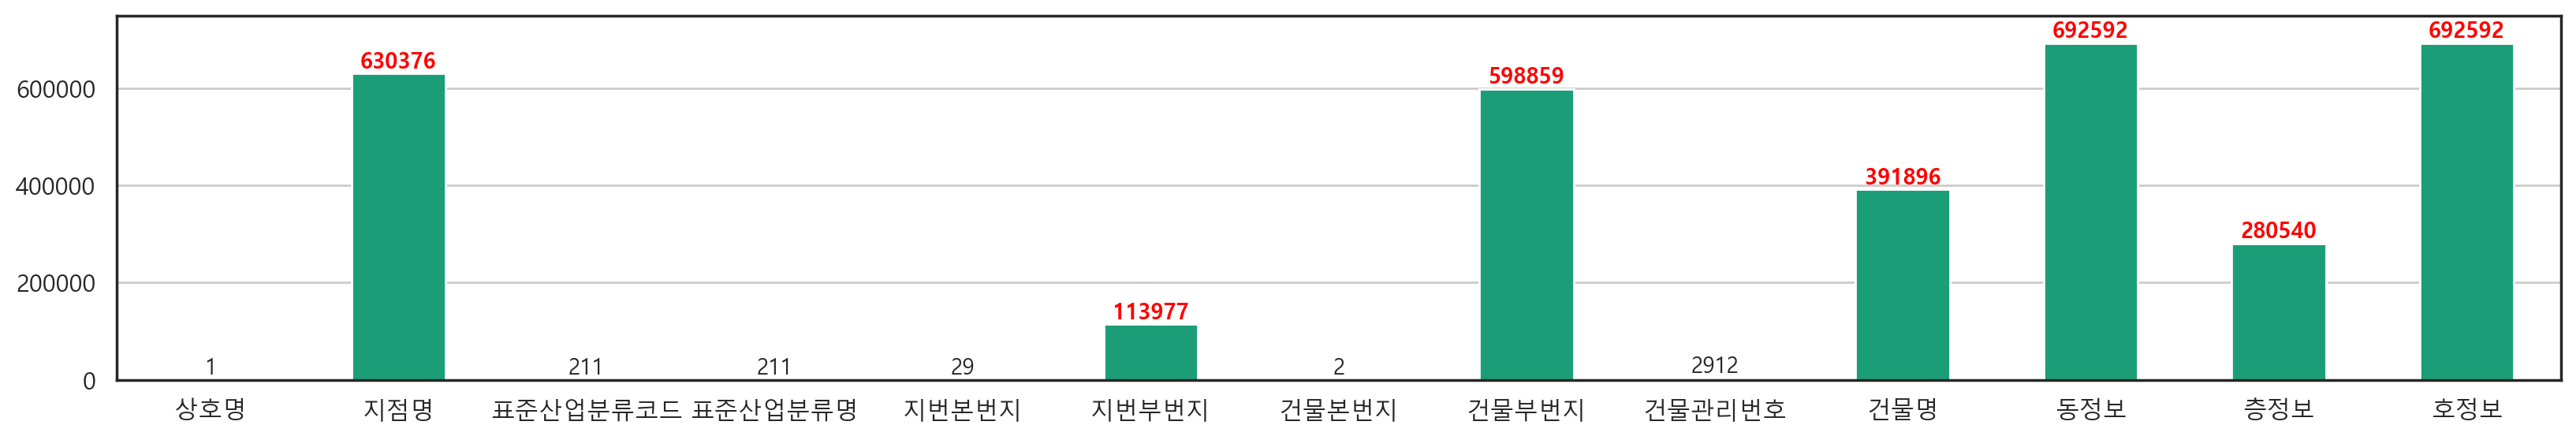

In [58]:
only_missing_cnt.plot(kind='bar', rot=0, figsize=(20,3),
                     ylim=[0, 750000])
for i, v in enumerate(only_missing_cnt):
    if v> 100000:
        plt.text(i, v, round(v), va='bottom', ha='center', size=10, color='r', weight='bold')
    else:
        plt.text(i, v, round(v), va='bottom', ha='center', size=10)
plt.grid(axis='y')

In [52]:
only_missing_cnt.to_frame()
# only_missing_cnt.to_frame().index *x축
# only_missing_cnt.to_frame()[0] * y축
# x축 : index
# y축 : 0열
result = only_missing_cnt.to_frame()
result.columns = ['결측치수']
result.head()

,결측치수
상호명,1
지점명,630376
표준산업분류코드,211
표준산업분류명,211
지번본번지,29


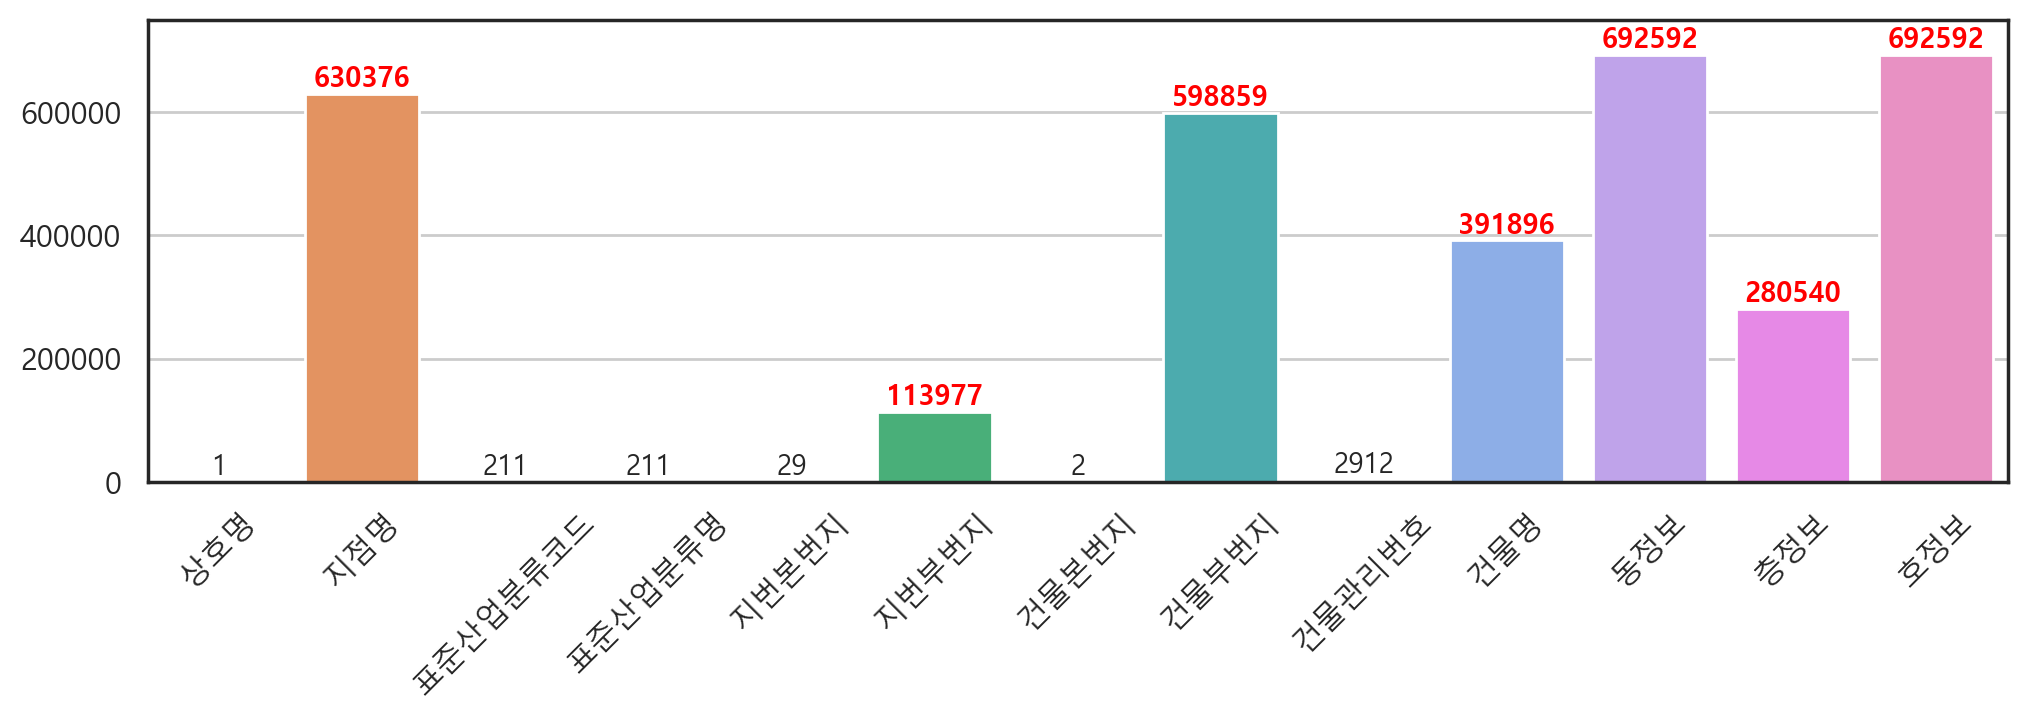

In [57]:
# sns.barplot(data=result, x=result.index, y='결측치수') == 아래와 같은 의미의 수식
sns.barplot(x=only_missing_cnt.index, y=only_missing_cnt)

for i, v in enumerate(only_missing_cnt):
    if v> 100000:
        plt.text(i, v, round(v), va='bottom', ha='center', size=10, color='r', weight='bold')
    else:
        plt.text(i, v, round(v), va='bottom', ha='center', size=10)

plt.ylim(0, 750000)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

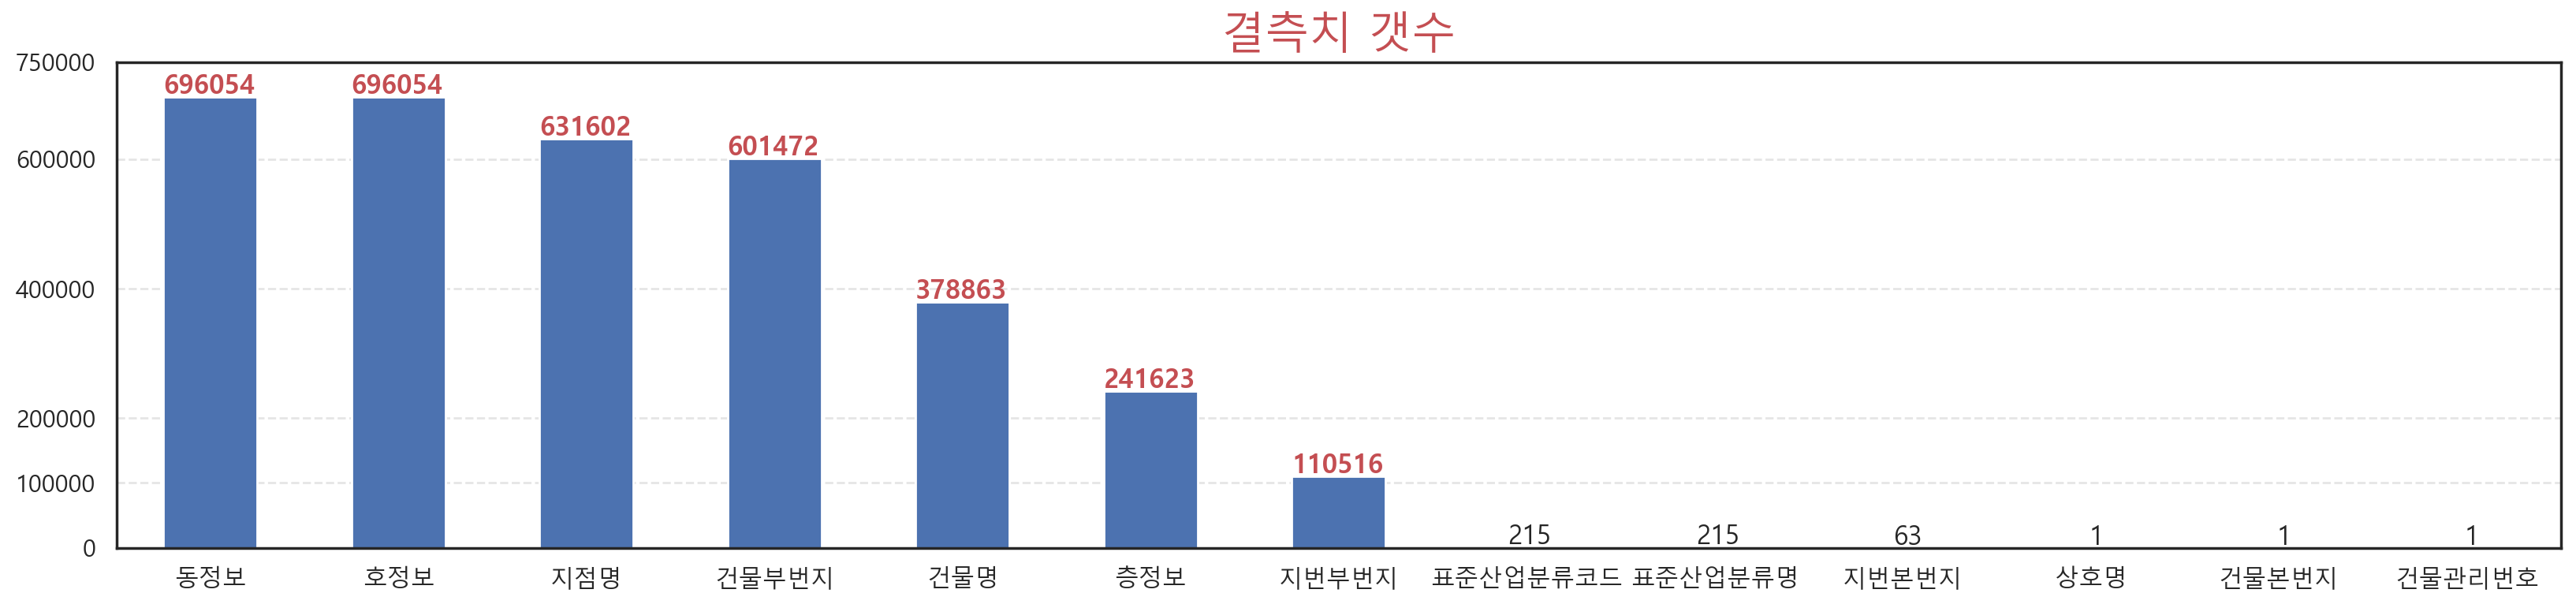

## ⑤ missingno 라이브러리로 결측치 시각화
* [ResidentMario/missingno: Missing data visualization module for Python](https://github.com/ResidentMario/missingno)

* 위의 사이트를 열어 사용법 확인 아나콘다 프롬프트에서 라이브러리 install:
`pip install missingno`

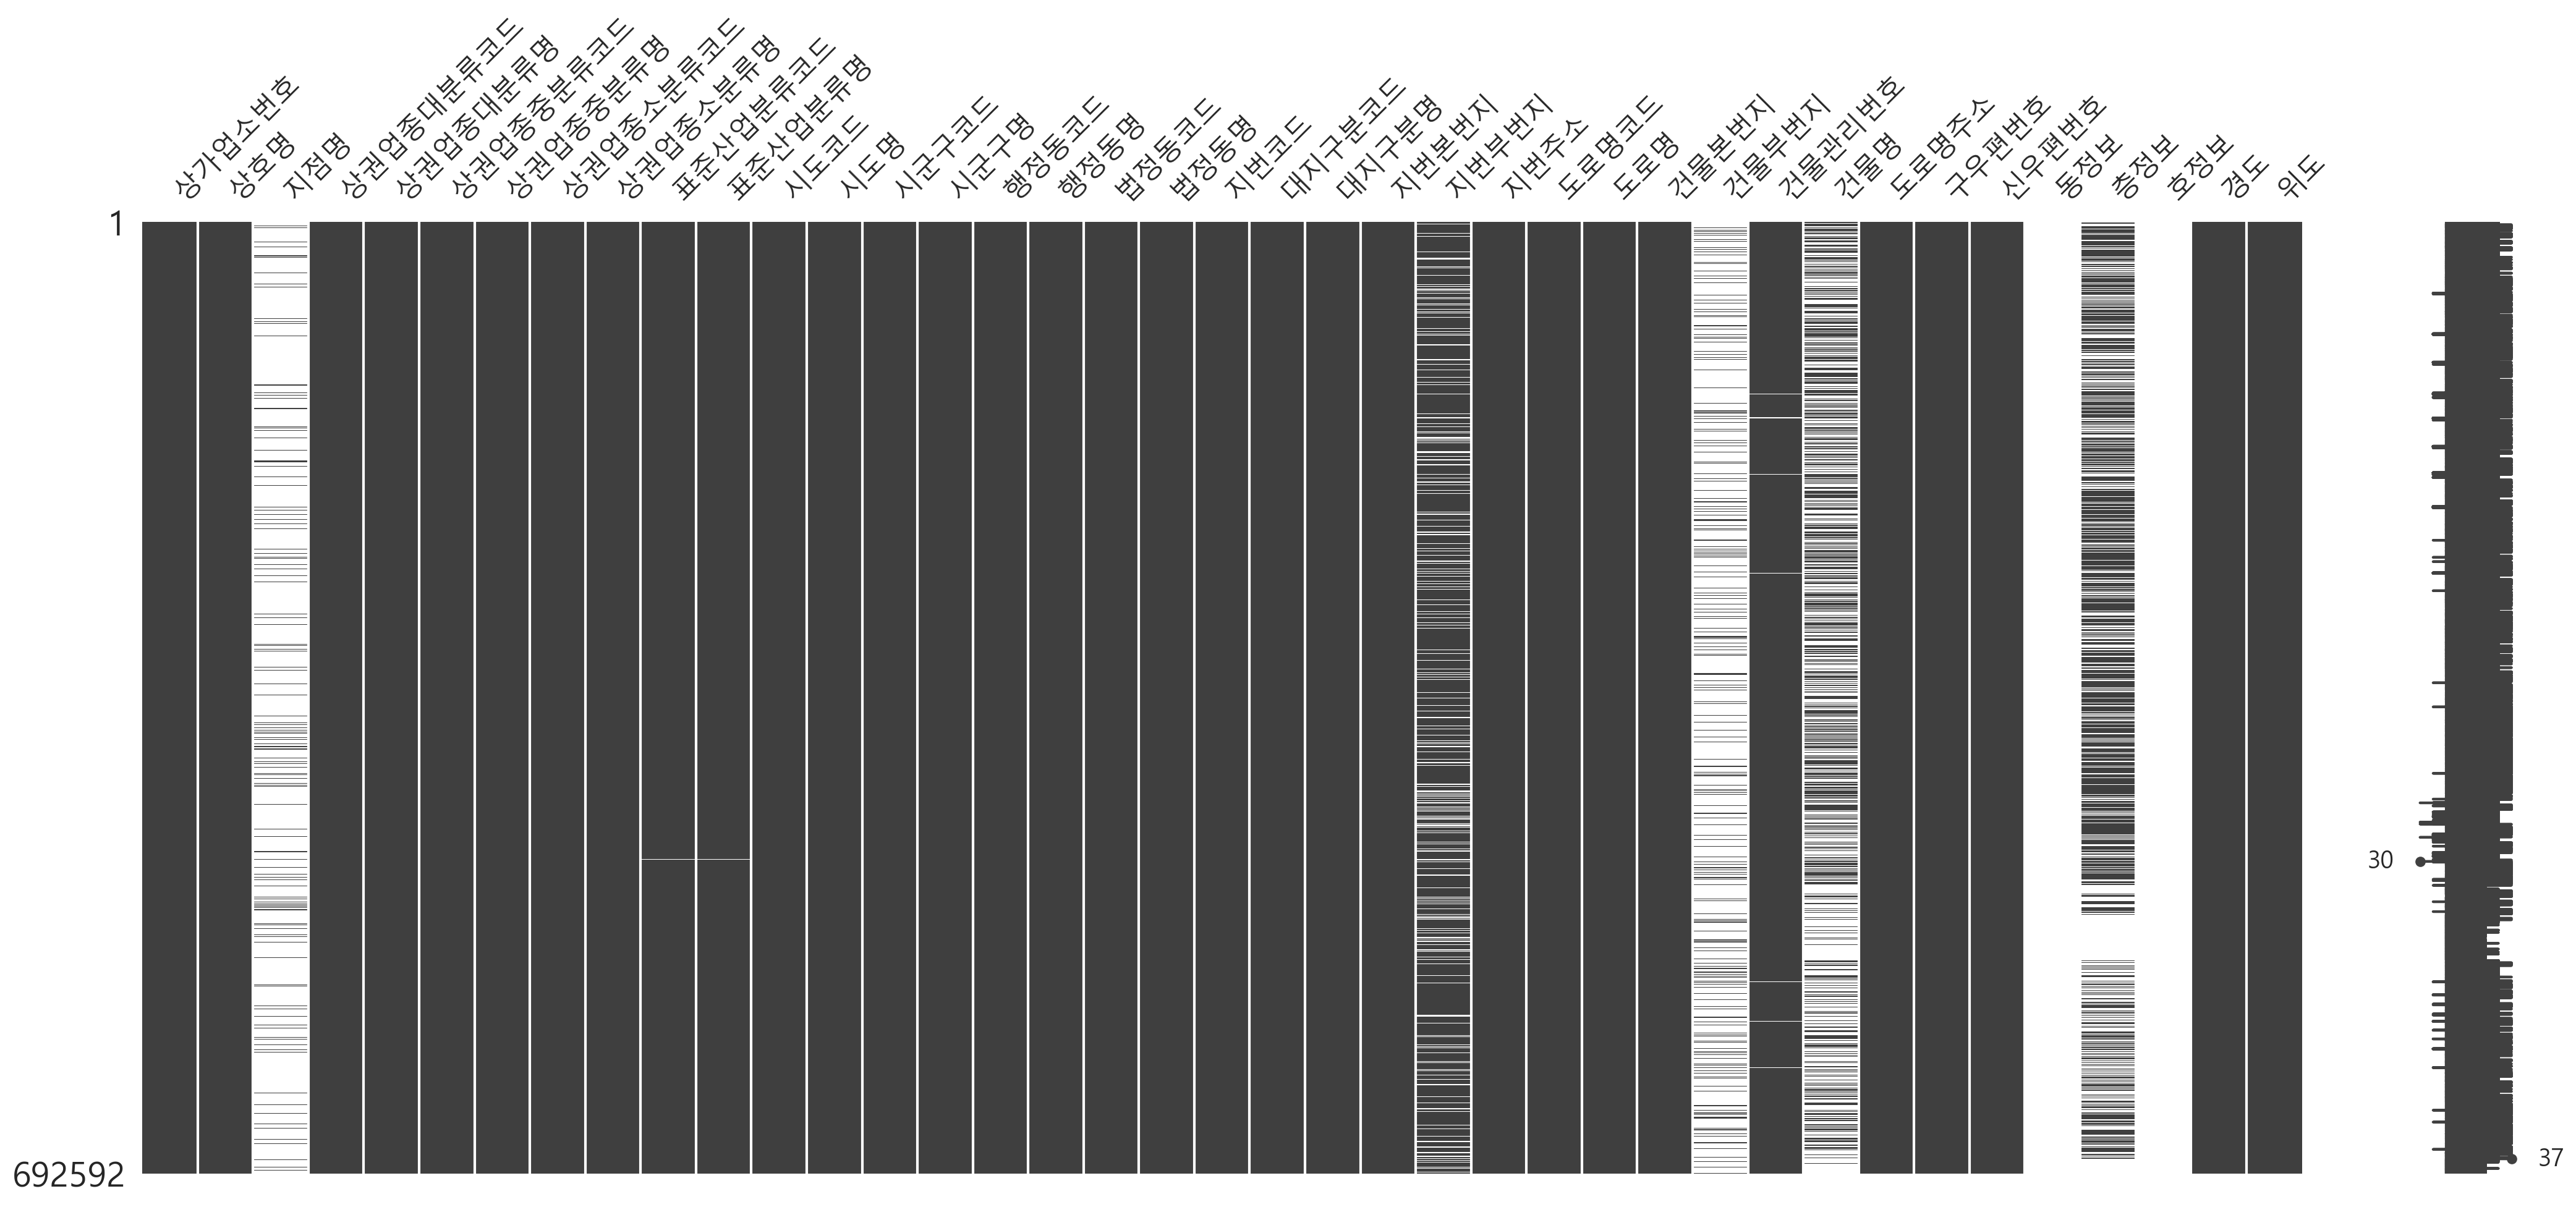

In [59]:
import missingno as msno
msno.matrix(df) # 결측치가 없는 부분은 검정색, 결측치 부분은 흰색
plt.show()

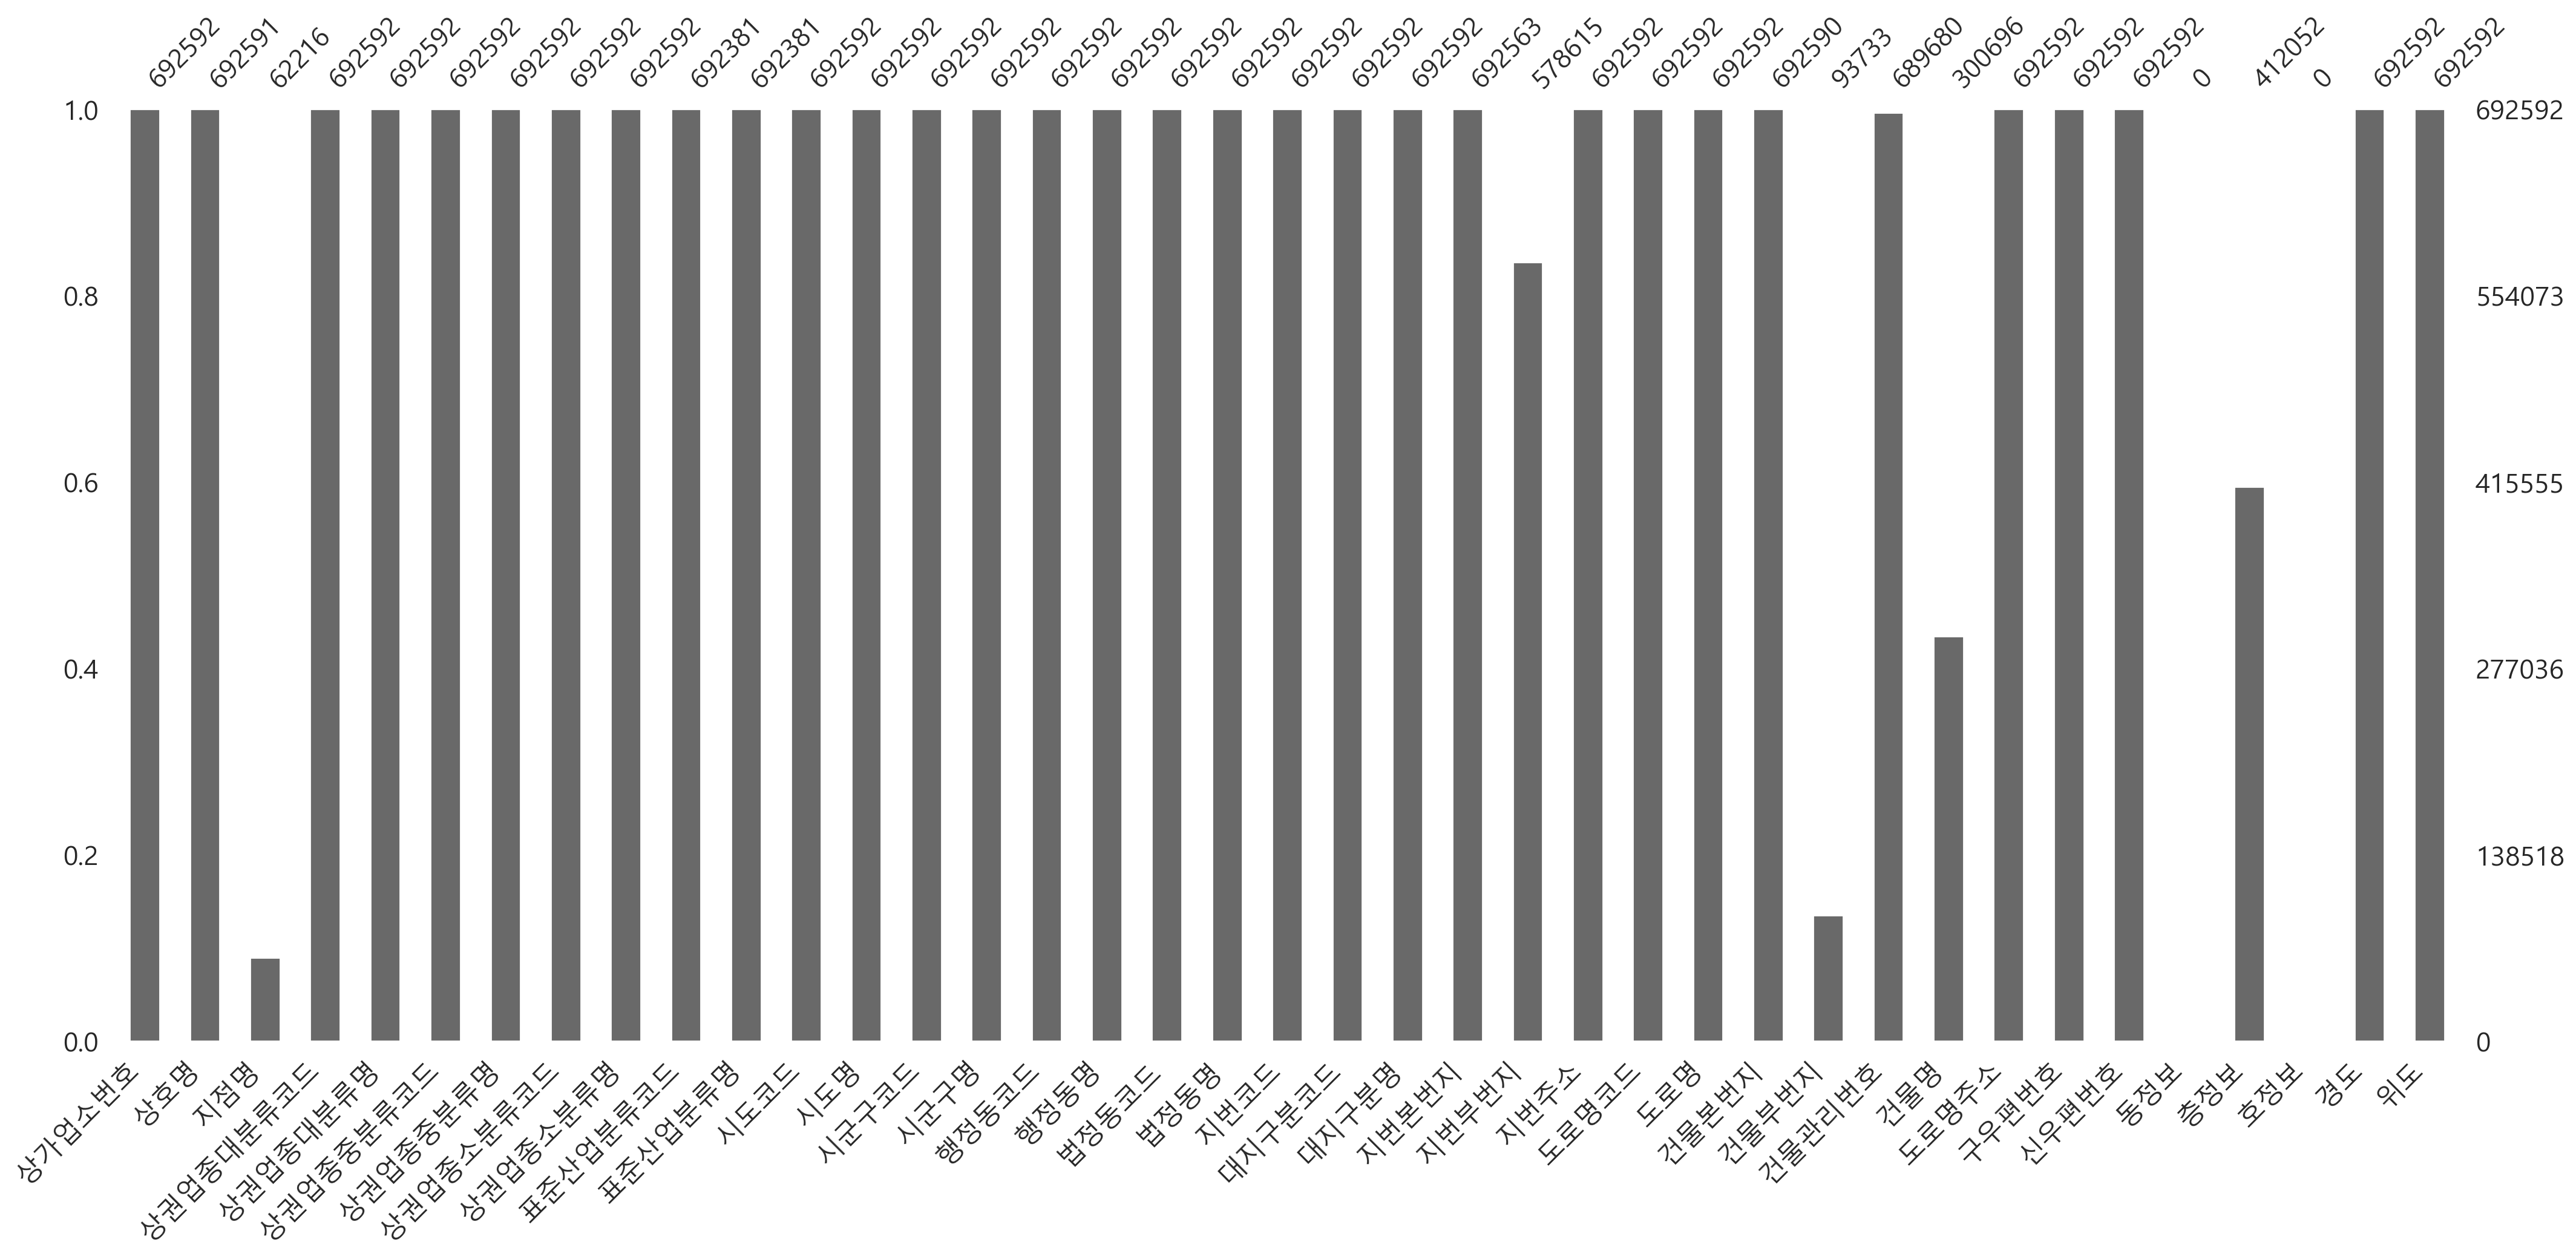

In [61]:
msno.bar(df) # 결측치가 아닌 데이터 갯수를 포함한 barplot 
plt.show()

# 4.	df 데이터 셋에서 사용하지 않을 컬럼은 제거
## ①결측치가 너무 많은 컬럼은 제거한다. 결측치가 너무 많은 상위 8개 컬럼은 제거함.


In [63]:
#결측치가 많은 컬럼명과 결측치 수
not_use = df.isnull().sum().sort_values(ascending=False).head(7)
not_use

호정보      692592
동정보      692592
지점명      630376
건물부번지    598859
건물명      391896
층정보      280540
지번부번지    113977
dtype: int64

In [65]:
# 결측치 비율
round(not_use / df.shape[0]*100, 2)

호정보      100.00
동정보      100.00
지점명       91.02
건물부번지     86.47
건물명       56.58
층정보       40.51
지번부번지     16.46
dtype: float64

In [66]:
# 삭제할 컬럼명
not_use.index

Index(['호정보', '동정보', '지점명', '건물부번지', '건물명', '층정보', '지번부번지'], dtype='object')

In [67]:
# 컬러 삭제전(206.1+MB), 컬럼수 39개
print('컬럼 제거 전 shape :', df.shape)
df = df.drop(not_use.index, axis=1)
# 컬럼 삭제 후 컬럼 수
print('컬럼 제거 후 shape :', df.shape)

컬럼 제거 전 shape : (692592, 39)
컬럼 제거 후 shape : (692592, 32)


## ②	컬럼명에 “코드”나 “번호”가 있는 컬럼은 분석에 사용되지 않을 예정입니다. 제거함

In [68]:
# 컬럼명
cols = df.columns
cols

Index(['상가업소번호', '상호명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드', '상권업종중분류명',
       '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드', '시도명', '시군구코드',
       '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드', '대지구분코드', '대지구분명',
       '지번본번지', '지번주소', '도로명코드', '도로명', '건물본번지', '건물관리번호', '도로명주소', '구우편번호',
       '신우편번호', '경도', '위도'],
      dtype='object')

**※ 시리즈에 문자함수를 쓰기 위해 참조 :**
https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

In [ ]:
# cols에 코드나 번호가 포함되어 있는 컬럼명 추출
cols[(cols.str.find('코드')!=-1) | (cols.str.find('번호')!=-1)]

In [72]:
drop_cols = cols[cols.str.contains('코드|번호')]
drop_cols

Index(['상가업소번호', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '표준산업분류코드', '시도코드',
       '시군구코드', '행정동코드', '법정동코드', '지번코드', '대지구분코드', '도로명코드', '건물관리번호', '구우편번호',
       '신우편번호'],
      dtype='object')

In [73]:
df.drop(drop_cols, axis=1, inplace=True)
print('열 제거 후 shape :', df.shape)

열 제거 후 shape : (692592, 17)


In [74]:
df.info() # 89.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상호명       692591 non-null  object 
 1   상권업종대분류명  692592 non-null  object 
 2   상권업종중분류명  692592 non-null  object 
 3   상권업종소분류명  692592 non-null  object 
 4   표준산업분류명   692381 non-null  object 
 5   시도명       692592 non-null  object 
 6   시군구명      692592 non-null  object 
 7   행정동명      692592 non-null  object 
 8   법정동명      692592 non-null  object 
 9   대지구분명     692592 non-null  object 
 10  지번본번지     692563 non-null  float64
 11  지번주소      692592 non-null  object 
 12  도로명       692592 non-null  object 
 13  건물본번지     692590 non-null  float64
 14  도로명주소     692592 non-null  object 
 15  경도        692592 non-null  float64
 16  위도        692592 non-null  float64
dtypes: float64(4), object(13)
memory usage: 89.8+ MB


# ※ df 파일io

In [75]:
df.to_csv('c:/ai/Downloads/shareData/상가정보/서울부산상가정보백업.csv', index=False)

In [ ]:
# 파일압축
df.to_csv('c:/ai/Downloads/shareData/상가정보/서울부산상가정보백업.csv.gz', index=False, compression='infer')

In [ ]:
# 압축파일 열기
df = df.read_csv('c:/ai/Downloads/shareData/상가정보/서울부산상가정보백업.csv.gz', compression='infer')
df.shatpe

In [9]:
# 일반 파일 열기
df = pd.read_csv('c:/ai/Downloads/shareData/상가정보/서울부산상가정보백업.csv')
df.shape

(692592, 17)

# 5. df 데이터 셋의 값을 가져온다(loc함수, iloc함수등을 사용하기도 하고 사용하지 않기도 하며 서브셋을 가져온다)
## ① 상호명 필드만 가져온다


In [ ]:
df['상호명']
df.loc[:, '상호명']

## ②상호명의 종류별 데이터수를 가져온다(df.상호명.value_counts()이용)

In [77]:
df['상호명'].unique()

array(['참편한공인중개사사무소', '60계치킨암사', '성심인력공사', ..., '제주식품', '신천횟집',
       '주식회사  스타라이팅 일광지점'], dtype=object)

In [78]:
# 상호명별 데이터 갯수
df.groupby('상호명')['경도'].count().sort_values(ascending=False).head(5)

상호명
업소명없음      793
컴퓨터수리      497
입시·교과학원    288
입주청소       262
김밥천국       214
Name: 경도, dtype: int64

In [79]:
df['상호명'].value_counts() # 정렬

업소명없음               793
컴퓨터수리               497
입시·교과학원             288
입주청소                262
김밥천국                214
                   ... 
손가네곰국수                1
대한어머니회서울시연합사          1
소월마인드풀요가              1
우림인쇄                  1
주식회사  스타라이팅 일광지점      1
Name: 상호명, Length: 535061, dtype: int64

## ③	“상호명”과 "도로명주소” 컬럼 가져오기

In [80]:
df[['상호명', '도로명주소']]

,상호명,도로명주소
0,참편한공인중개사사무소,서울특별시 서초구 방배로19길 25
1,60계치킨암사,서울특별시 강동구 상암로3길 8
2,성심인력공사,서울특별시 용산구 한강대로 385
3,칸토빈,서울특별시 강서구 방화동로 30
4,까치노래연습장,서울특별시 노원구 한글비석로23길 2
...,...,...
692587,사회적협동조합 희망드림,부산광역시 동구 조방로 14
692588,제주식품,부산광역시 남구 동명로152번길 93
692589,신천횟집,부산광역시 중구 자갈치해안로 52
692590,주식회사 스타라이팅 일광지점,부산광역시 기장군 일광읍 일광로 808


## ④ 0~2행을 출력하라 (head()함수를 이용하지 않고, loc과 iloc을 이용)

In [81]:
df.loc[:2]
df.iloc[:3]
df[:3] # 조건, 열이름, 행슬라이스 등이 데이터프레임변수 []안에(열슬라이싱은 불가)

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803


# 6. 기술 통계값 보기 

- [Descriptive statistics - Wikipedia](https://en.wikipedia.org/wiki/Descriptive_statistics)
- [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
- [표준 편차 - 위키백과, 우리 모두의 백과사전](https://ko.wikipedia.org/wiki/표준편차)
* describe()를 사용하면 데이터 요약을 볼 수 있음(기술통계량)
    - 기본적으로 수치형 데이터를 요약
    - include, exclude 옵션으로 다른 데이터 타입의 요약 수치 출력
    - count, min, max, mean, median, 1사분위수, 3사분위수

### **개별 기술 통계값 구하기**

* [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
* count : 결측치를 제외한 값 갯수
* min, max: 최솟값, 최댓값
* argmin, argmax : 최솟값 인덱스, 최댓값 인덱스 반환
* quantile 특정 사분위수에 해당하는 값을 반환 (0~1 사이)
    * 0.25 : 1사분위 수
    * 0.5 : 2사분위수 (quantile 의 기본 값)
    * 0.75 : 3사분위수
* sum 수치 데이터의 합계
* mean 평균
* median 중앙값(중간값:데이터를 한 줄로 세웠을 때 가운데 위치하는 값, 중앙값이 짝수일 때는 가운데 2개 값의 평균을 구함)

* std, var 표준편차, 분산을 계산
* cumsum 맨 첫 번째 성분부터 각 성분까지의 누적합을 계산 (0 번째 부터 계속 더해짐)
* cumprod 맨 첫번째 성분부터 각 성분까지의 누적곱을 계산 (1 번째 부터 계속 곱해짐)
* cov, corr() : 공분산, 상관계수
* skew 왜도 (오른쪽으로 치우침= 왜도<0, 왼쪽으로 치우침=왜도>0)
* kurt 첨도


## ①	df 데이터셋의 요약기술 통계량

In [82]:
df.describe() # 수치형에 대한 기술통계량

,지번본번지,건물본번지,경도,위도
count,692563.000000,692590.000000,692592.000000,692592.000000
mean,484.421211,144.045545,127.457120,37.008934
std,518.267621,264.093185,0.867369,0.991261
min,1.000000,1.000000,126.767661,34.989747
25%,112.000000,19.000000,126.943926,37.474629
50%,337.000000,47.000000,127.034613,37.514822
75%,688.000000,152.000000,127.131254,37.560404
max,6435.000000,3646.000000,129.294072,37.692604


In [83]:
df.describe(include='object') # object형에 대한 기술 통계량

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번주소,도로명,도로명주소
count,692591,692592,692592,692592,692381,692592,692592,692592,692592,692592,692592,692592,692592
unique,535061,10,75,247,386,2,39,630,647,2,221186,18817,220936
top,업소명없음,음식,한식,백반/한정식,한식 일반 음식점업,서울특별시,강남구,역삼1동,서초동,대지,서울특별시 송파구 문정동 634,서울특별시 강남구 테헤란로,서울특별시 송파구 충민로 66
freq,793,190725,75607,39765,60780,537489,64239,13420,17901,691744,881,4248,1123


## ②	df 데이터셋의 “지번본번지", "건물본번지” 컬럼의 데이터 개수와  dtype 메모리 사용량을 확인한다.

In [85]:
df[['지번본번지', '건물본번지']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   지번본번지   692563 non-null  float64
 1   건물본번지   692590 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


## ③	“위도", "경도” 컬럼만의 요약 기술통계량

In [86]:
df[['위도', '경도']].describe()
# 오른쪽 꼬리가 긴분포(데이터가 왼쪽으로 치우침) : 중위수 < 평균 - 왜도(skew)>0
# 왼쪽 꼬리가 긴분포(데이터가 오른쪽으로 치우침) : 중위수 > 평균 - 왜도(skew)<0

,위도,경도
count,692592.000000,692592.000000
mean,37.008934,127.457120
std,0.991261,0.867369
min,34.989747,126.767661
25%,37.474629,126.943926
50%,37.514822,127.034613
75%,37.560404,127.131254
max,37.692604,129.294072


# 7.단별량 수치형 변수 시각화
## ① 위도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

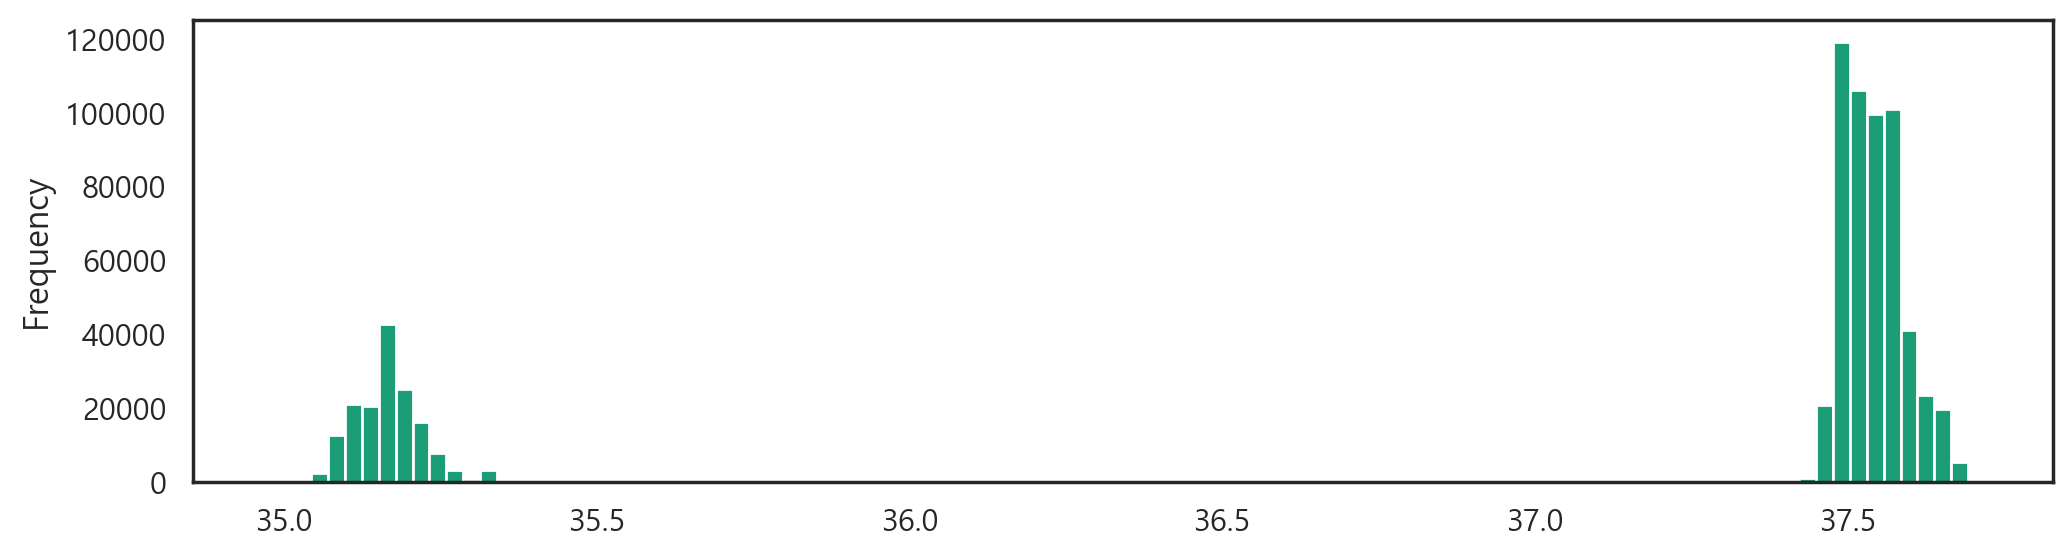

In [87]:
# df['위도'].plot(kind='hist', bins=100)
df['위도'].plot.hist(bins=100)
plt.show()

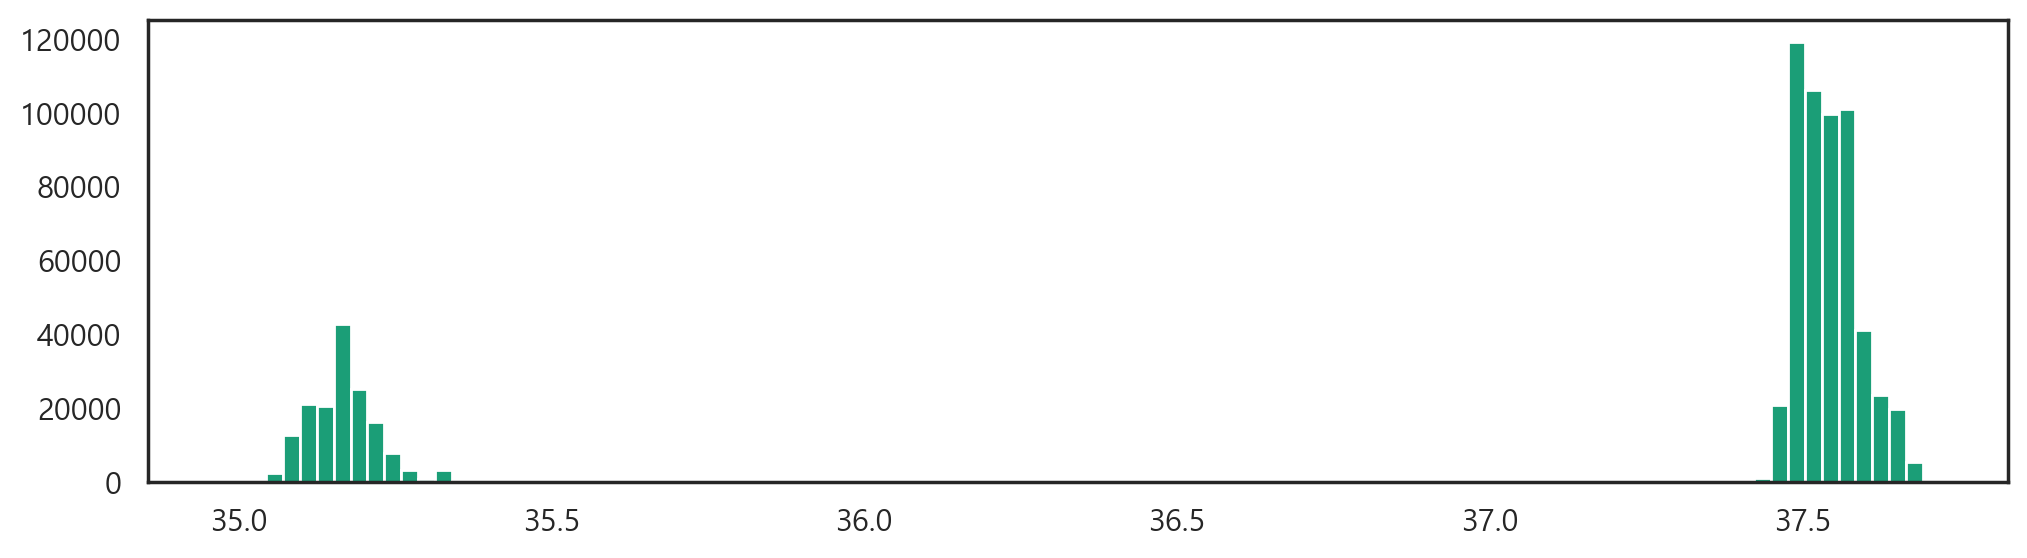

In [88]:
plt.hist(df['위도'], bins=100)
plt.show()

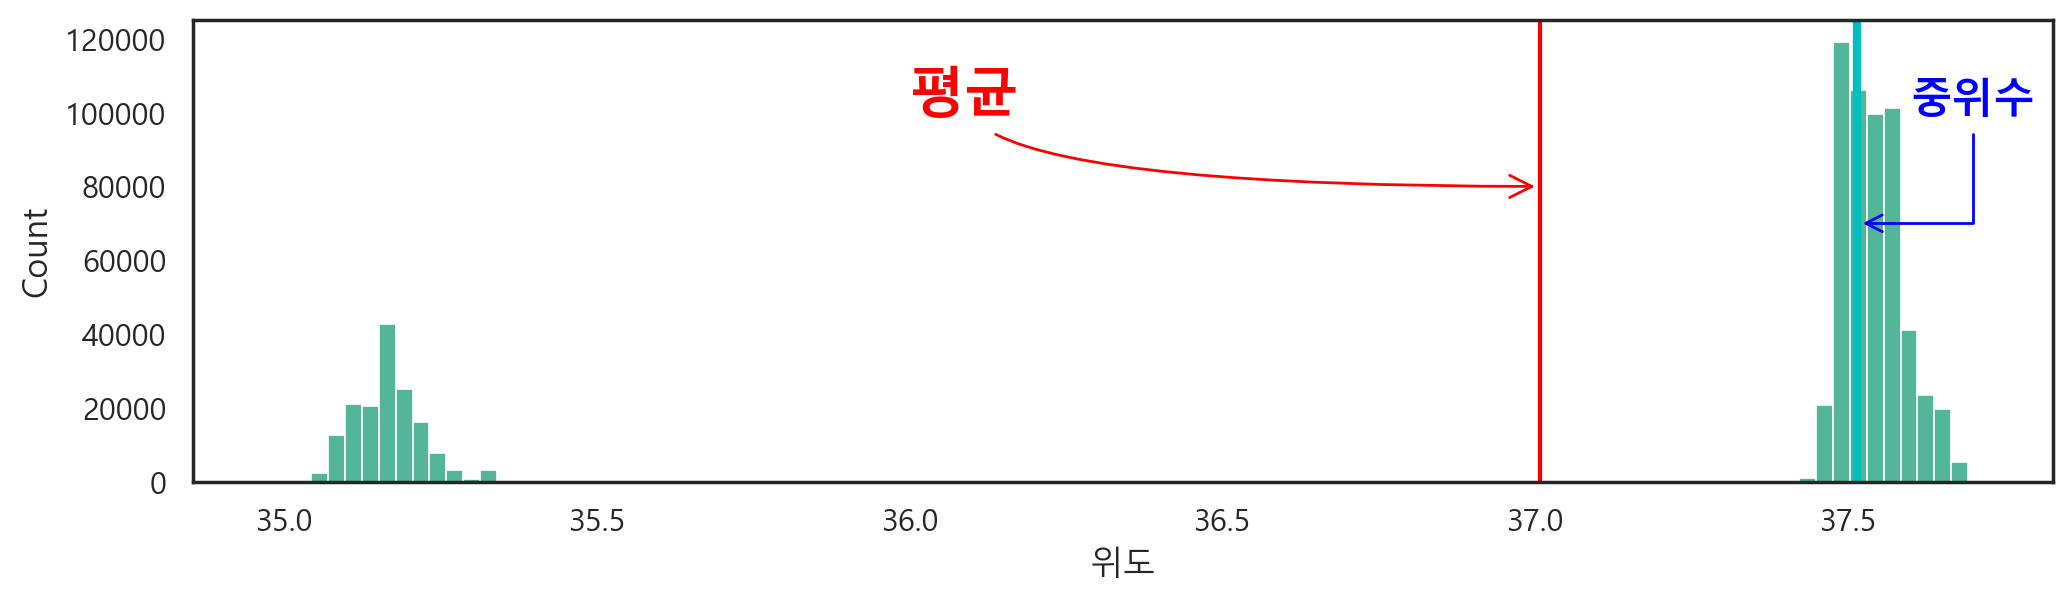

In [99]:
sns.histplot(data=df, x='위도', bins=100)
plt.axvline(df['위도'].mean(), color='r')
plt.annotate('평균', 
             xytext=(36, 100000), 
             xy = (df['위도'].mean(), 80000),
             arrowprops={'arrowstyle':'->',
                       'connectionstyle':'angle3',
                       'color':'r'},
             fontsize=20,
             weight='bold',
             color='r' 
            )
plt.axvline(df['위도'].median(), color='c', linewidth=3)
plt.annotate('중위수', xytext=(37.6, 100000), xy=(df['위도'].median(), 70000),
            arrowprops=dict(arrowstyle='->',
                           connectionstyle='angle',
                           color='b'),
            color='b',
            weight='bold',
            fontsize=15)
plt.show()

## ② 경도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

In [ ]:
sns.histplot(data=df, x='경도', bins=100)
plt.axvline('평균',
           xytext=(127.7, 60000),
           xy=(df['경도'].meann(), 70000),
           arrowprops={'arrowstyle':'->',
                      'connectionstyle':'angle3',
                      'color':'r'},
           fontsize=20,
           weight='bold',
           color='r')
plt.axline(df['위도'].mean)

In [ ]:
df

# 8. 상관계수
-  두 변수 간에 어떤 선형적 관계를 갖고 있는 지를 분석하는 방법
- [상관 분석 - 위키백과, 우리 모두의 백과사전M](https://ko.wikipedia.org/wiki/상관_분석) 

- 결과의 해석 : r 값은 X 와 Y 가 완전히 동일하면 +1, 전혀 다르면 0, 반대방향으로 완전히 동일 하면 –1 을 가진다. 결정계수(coefficient of determination)는 $r^2$로 계산하며 이것은 X 로부터 Y를 예측할 수 있는 정도를 의미한다.
- ([수학기호 사이트 참조](https://matplotlib.org/2.0.2/users/mathtext.html))

- 일반적으로
    * r이 -1.0과 -0.7 사이이면, 강한 음적 선형관계,
    * r이 -0.7과 -0.3 사이이면, 뚜렷한 음적 선형관계,
    * r이 -0.3과 -0.1 사이이면, 약한 음적 선형관계,
    * r이 -0.1과 +0.1 사이이면, 거의 무시될 수 있는 선형관계,
    * r이 +0.1과 +0.3 사이이면, 약한 양적 선형관계,
    * r이 +0.3과 +0.7 사이이면, 뚜렷한 양적 선형관계,
    * r이 +0.7과 +1.0 사이이면, 강한 양적 선형관계로 해석한다.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png" width="600">

이미지 출처 : [위키백과](https://ko.wikipedia.org/wiki/상관_분석)


## ① 전체 숫자 컬럼끼리의 상관계수

In [100]:
# df[['지번본번지', '건물본번지', '경도', '위도']].corr()
corr = df.corr(numeric_only=True)
corr

,지번본번지,건물본번지,경도,위도
지번본번지,1.000000,0.056225,0.171947,-0.192398
건물본번지,0.056225,1.000000,-0.007447,0.013710
경도,0.171947,-0.007447,1.000000,-0.993558
위도,-0.192398,0.013710,-0.993558,1.000000


## ②	상관계수를 이용하여 heatmap 시각화
- 참조 http://seaborn.pydata.org/examples/many_pairwise_correlations.html 

In [ ]:
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu', vmin=-1, vmax=1)
plt.show()

# 9.	경도와 위도 컬럼을 이용하여 산점도

[Anscombe’s quartet — seaborn 0.10.0 documentation](https://seaborn.pydata.org/examples/anscombes_quartet.html)

## ①	X축에는 경도, y축에는 위도 컬럼을 산점도로 시각화

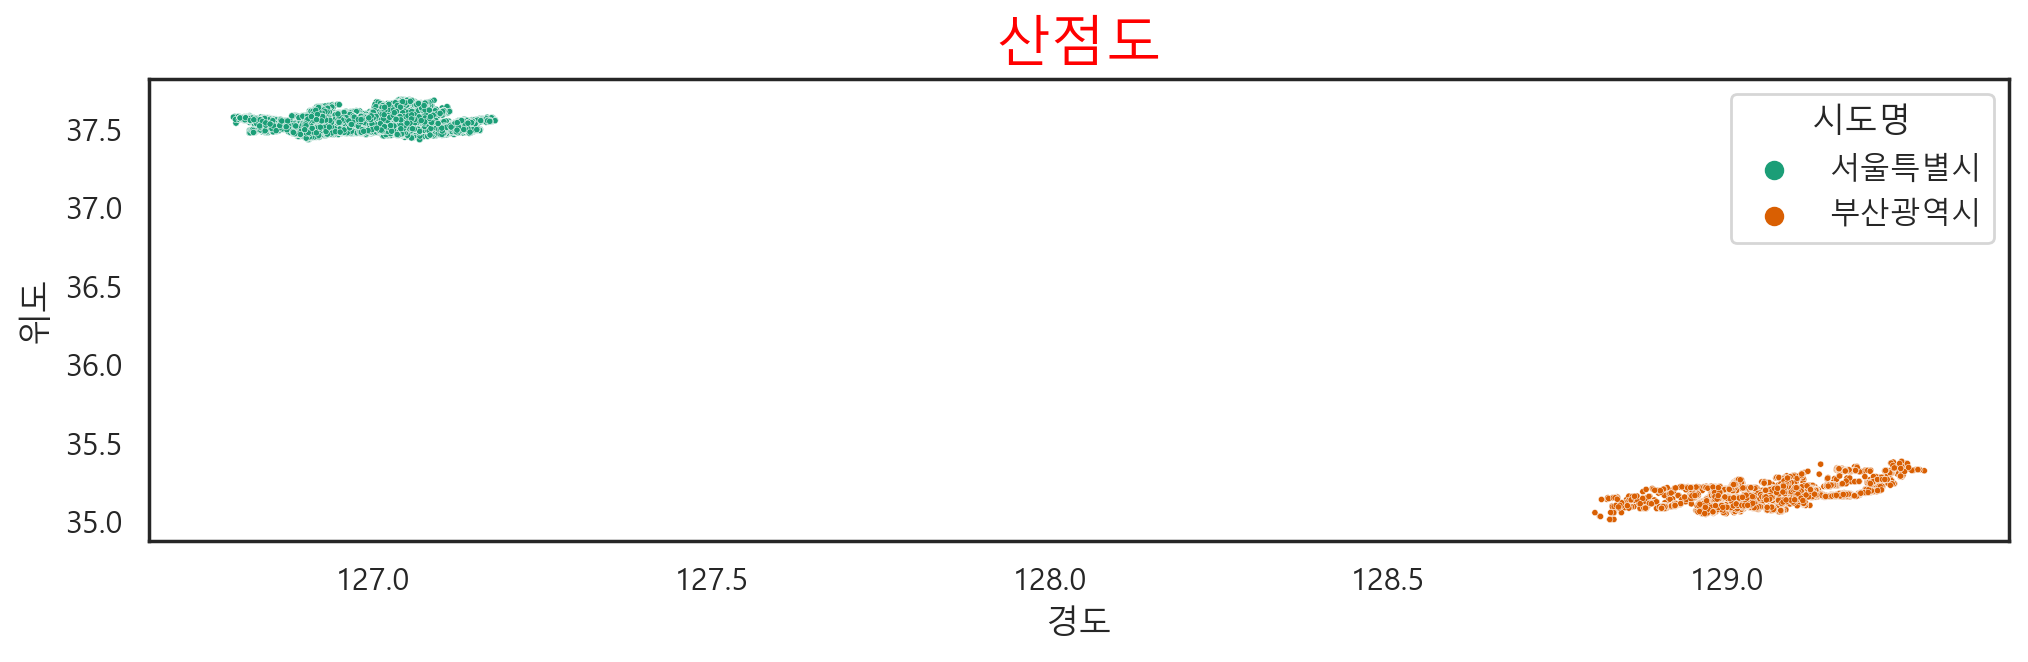

CPU times: total: 3.39 s
Wall time: 3.39 s


In [103]:
%%time
ax = sns.scatterplot(data=df.sample(frac=0.1), x='경도', y='위도', s=5, hue='시도명')
ax.set_title('산점도', color='r', fontsize=20)
plt.title('산점도', color='r', fontsize=20)
plt.show()

In [104]:
df.shape

(692592, 17)

## ②	경도와 위도의 산점도를 “시도명” 컬럼별로 서브플롯으로 시각화

In [105]:
df['시도명'].uniqueque()

array(['서울특별시', '부산광역시'], dtype=object)

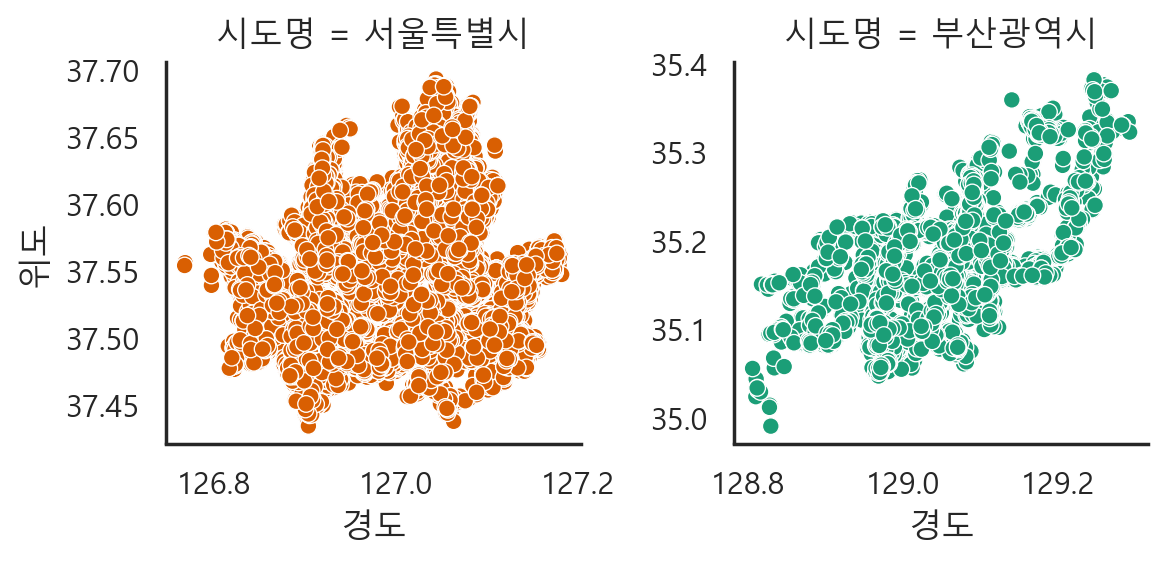

CPU times: total: 4.72 s
Wall time: 4.71 s


In [110]:
%%time
    g = sns.relplot(data=df.sample(frac=0.1),
              x='경도', y='위도', hue='시도명',
              col='시도명',
              # kind='scatter',
              facet_kws={'sharey':False, 'sharex':False},
              height=3, #높이 지정(인치)
              aspect=1, #가로세로 비율
              legend=False, #범례 안보이게
              col_order=['서울특별시', '부산광역시'] # 서브플롯의 순서
              )
# 사이즈 조절 : g.fig.set_size_inches(10,5)

plt.tight_layout() # 서브플롯의 겹침방지
plt.show()

## ③ 위의 1번에서 시각화된 산점도를 바탕으로 회귀선을 그린다.

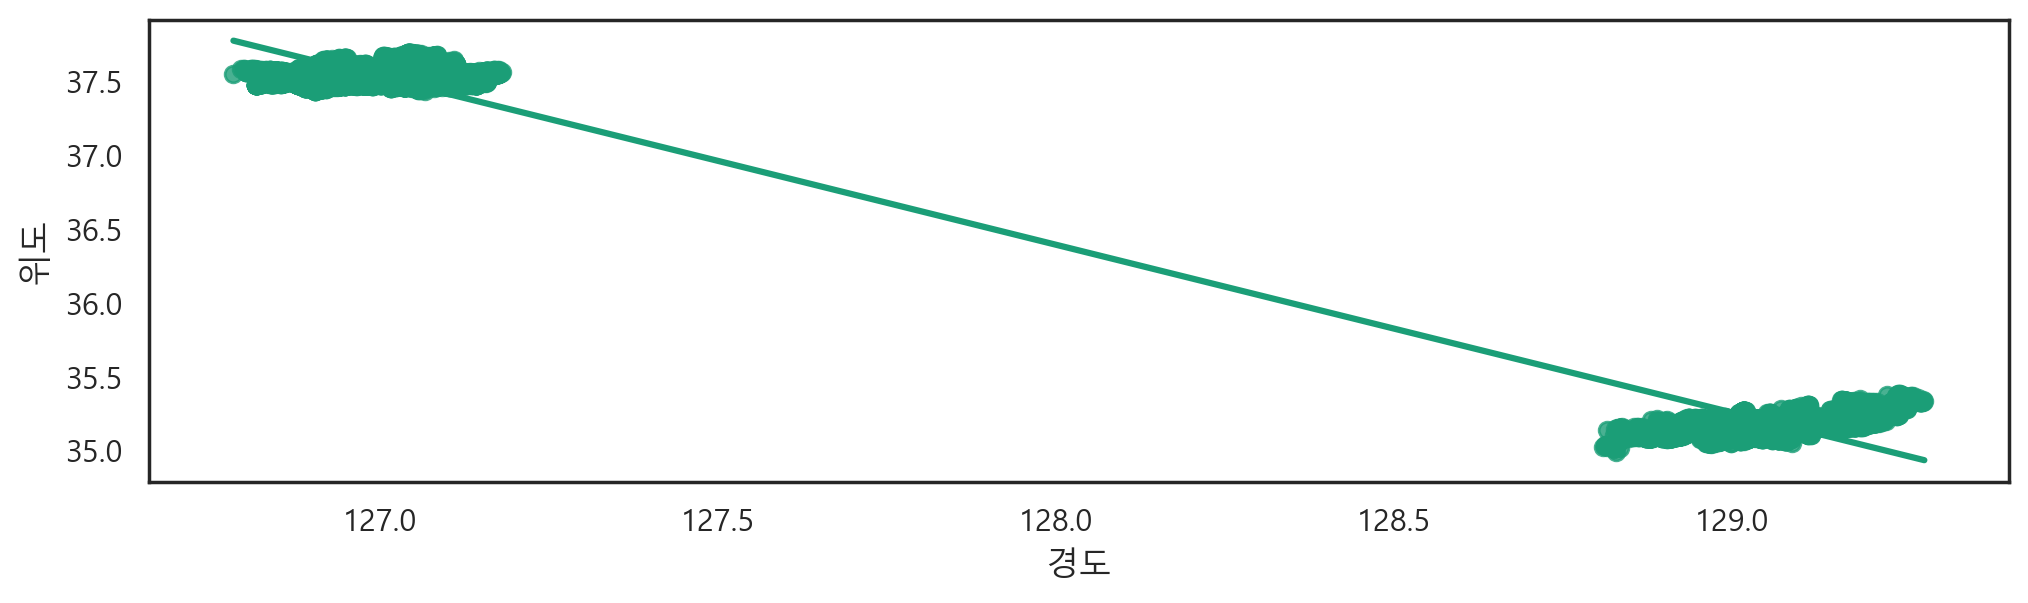

In [113]:
sns.regplot(data=df.sample(frac=0.1), x='경도', y='위도')
plt.show()

## ④ 위의 2번에서 시각화된 산점도를 바탕으로 회귀선을 서브 플롯으로 그린다.

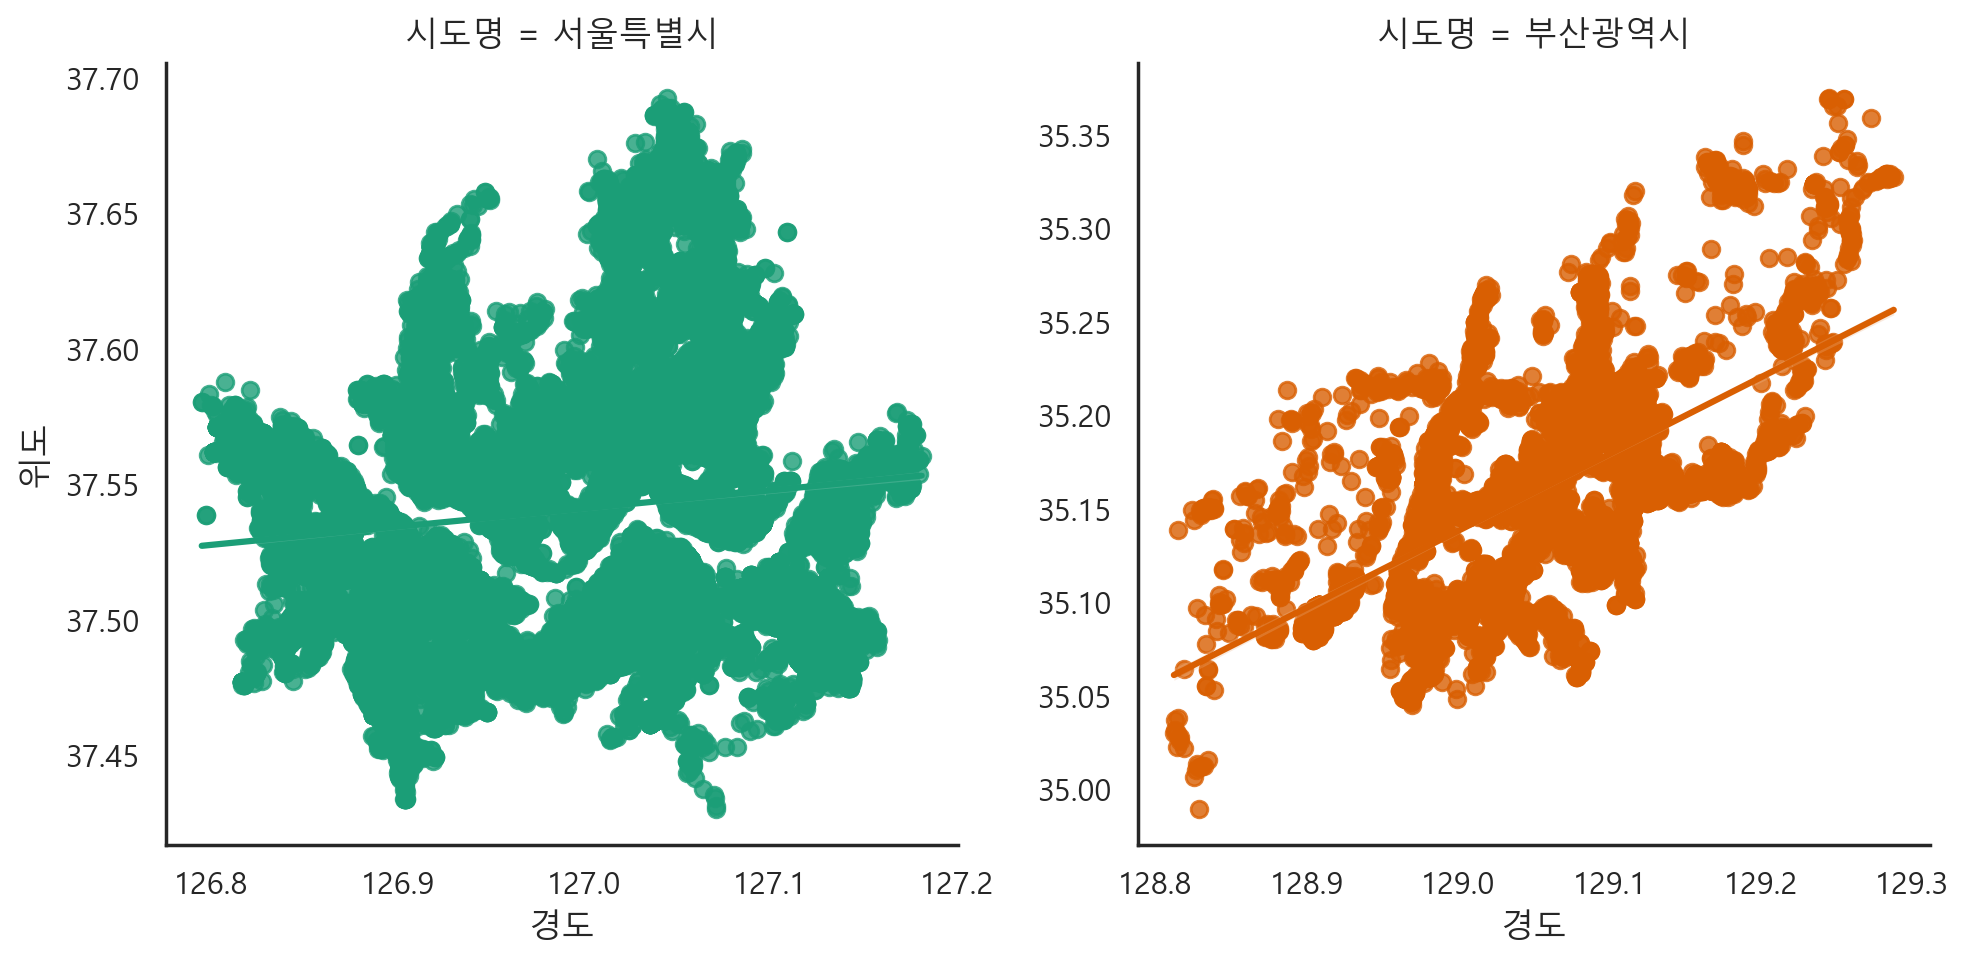

In [116]:
sns.lmplot(data=df.sample(frac=0.1), x='경도', y='위도', hue='시도명',
          col='시도명', 
           facet_kws={'sharey':False, 'sharex':False})
g.fig.set_size_inches(5,3)
plt.show()

# 10. 상권업종대분류명별 상호명의 개수를 도출하고 시각화하기

In [11]:
# 상호명이 결측치인 행
# df['상호명'].isna().sum() 상호명 결측치 1행
df[df['상호명'].isna()]

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
598904,NaN,소매,섬유·의복·신발 소매,신발 소매업,신발 소매업,부산광역시,부산진구,부전2동,부전동,대지,573.0,부산광역시 부산진구 부전동 573-1,부산광역시 부산진구 중앙대로,717.0,부산광역시 부산진구 중앙대로 717,129.059138,35.155237


In [12]:
df['상권업종대분류명'].unique()

array(['부동산', '음식', '시설관리·임대', '예술·스포츠', '소매', '과학·기술', '수리·개인', '보건의료',
       '숙박', '교육'], dtype=object)

In [13]:
# 상호명 결측치를 포함한 상권업종대분류별 데이터 갯수
df['상권업종대분류명'].value_counts()

음식         190725
소매         151515
과학·기술      105271
수리·개인       72510
교육          53257
부동산         30484
시설관리·임대     29404
예술·스포츠      26690
보건의료        21394
숙박          11342
Name: 상권업종대분류명, dtype: int64

In [16]:
# 상권업종대분류별 상호명 갯수(결측치 제외)
df.groupby('상권업종대분류명')['상호명'].count().sort_values(ascending=False) # 시리즈

df.groupby('상권업종대분류명', as_index=False)['상호명'].count().sort_values(by='상호명', ascending=False) #데이트 프레임
df.pivot_table(index='상권업종대분류명',
              values='상호명',
              aggfunc='count').sort_values(by='상호명', ascending=False)

result = df.pivot_table(index='상권업종대분류명',
              values='상호명',
              aggfunc='count').sort_values(by='상호명', ascending=False).reset_index()
result

,상권업종대분류명,상호명
0,음식,190725
1,소매,151514
2,과학·기술,105271
3,수리·개인,72510
4,교육,53257
5,부동산,30484
6,시설관리·임대,29404
7,예술·스포츠,26690
8,보건의료,21394
9,숙박,11342


In [ ]:
df.groupby('상권업종대분류명')['상호명'].count().sort_values(ascending=False).plot.bar(rot=0)

In [ ]:
result.plot(kind='bar')
# ax.set_xticklabels(result['상권업종대분류명'])
plt.xticks(
ticks=range(len(result)),
labels=result['상권업종대분류명'])
plt.show()

In [ ]:
# sns.barplot(data=result, x='상권업종대분류명', y='상호명')
           #estimator='mean' 
sns.countplot(data=df, x='상권업종대분류명', order=result['상권업종대분류명'])
for i, val in enumerate(result['상호명']):
    plt.text(i, val, val, va='bottom', ha='center')
plt.ylim([0, 220000])
plt.show()

In [27]:
group=df.groupby(['상권업종대분류명', '상권업종중분류명', '상권업종소분류명'])
print(len(group))
list(group)
for(major, medium, sub), df_val in group:
    if major=='음식':
        print(f'{major}-{medium}-{sub}')

247
음식-구내식당·뷔페-구내식당
음식-구내식당·뷔페-뷔페
음식-기타 간이-그 외 기타 간이 음식점
음식-기타 간이-김밥/만두/분식
음식-기타 간이-떡/한과
음식-기타 간이-버거
음식-기타 간이-빵/도넛
음식-기타 간이-아이스크림/빙수
음식-기타 간이-치킨
음식-기타 간이-토스트/샌드위치/샐러드
음식-기타 간이-피자
음식-기타 외국-분류 안된 외국식 음식점
음식-동남아시아-기타 동남아식 전문
음식-동남아시아-베트남식 전문
음식-비알코올 -카페
음식-서양식-경양식
음식-서양식-기타 서양식 음식점
음식-서양식-파스타/스테이크
음식-서양식-패밀리레스토랑
음식-일식-기타 일식 음식점
음식-일식-일식 면 요리
음식-일식-일식 카레/돈가스/덮밥
음식-일식-일식 회/초밥
음식-주점-무도 유흥 주점
음식-주점-생맥주 전문
음식-주점-요리 주점
음식-주점-일반 유흥 주점
음식-중식-마라탕/훠궈
음식-중식-중국집
음식-한식-곱창 전골/구이
음식-한식-국/탕/찌개류
음식-한식-국수/칼국수
음식-한식-기타 한식 음식점
음식-한식-냉면/밀면
음식-한식-닭/오리고기 구이/찜
음식-한식-돼지고기 구이/찜
음식-한식-백반/한정식
음식-한식-복 요리 전문
음식-한식-소고기 구이/찜
음식-한식-전/부침개
음식-한식-족발/보쌈
음식-한식-해산물 구이/찜
음식-한식-횟집


# 11. 상권업종대분류명이 음식인 서브셋을 이용한 분석

## ① “상권업종대분류명”이 음식인 서브셋을 변수 df_food에 할당하고 확인

In [28]:
df_food = df[df['상권업종대분류명']=='음식']
df_food.shape

(190725, 17)

In [29]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상호명       692591 non-null  object 
 1   상권업종대분류명  692592 non-null  object 
 2   상권업종중분류명  692592 non-null  object 
 3   상권업종소분류명  692592 non-null  object 
 4   표준산업분류명   692381 non-null  object 
 5   시도명       692592 non-null  object 
 6   시군구명      692592 non-null  object 
 7   행정동명      692592 non-null  object 
 8   법정동명      692592 non-null  object 
 9   대지구분명     692592 non-null  object 
 10  지번본번지     692563 non-null  float64
 11  지번주소      692592 non-null  object 
 12  도로명       692592 non-null  object 
 13  건물본번지     692590 non-null  float64
 14  도로명주소     692592 non-null  object 
 15  경도        692592 non-null  float64
 16  위도        692592 non-null  float64
dtypes: float64(4), object(13)
memory usage: 890.0 MB


In [ ]:
# 구별 상호명수
df_food.groupby('시군구명')['상호명'].count().sort_values(ascending=False)
df_food['시군구명'].value_counts()

## ②	“상권업종대분류명”이 음식이면서, "시군구명”이 강남구 데이터만 가져와 “상권업종중분류명”별로 빈도수를 구함(loc함수를 이용 vs loc함수 이용안함)

In [31]:
df_food[df_food['시군구명']=='강남구']['상권업종중분류명'].value_counts()

한식         4672
비알코올       2093
기타 간이      1956
주점         1100
서양식        1094
일식          920
중식          439
동남아시아       174
구내식당·뷔페     128
기타 외국         2
Name: 상권업종중분류명, dtype: int64

In [33]:
# 속도 빠름
df_food.loc[df_food['시군구명']=='강남구', '상권업종중분류명'].value_counts()

한식         4672
비알코올       2093
기타 간이      1956
주점         1100
서양식        1094
일식          920
중식          439
동남아시아       174
구내식당·뷔페     128
기타 외국         2
Name: 상권업종중분류명, dtype: int64